# **Segment & Risk Index**

## 데이터 불러오기

In [1]:
# 데이터 처리
import numpy as np                          # 수치 계산/벡터·행렬 연산
import pandas as pd                         # 데이터프레임 생성·가공·요약

# 시각화
import matplotlib.pyplot as plt             # 기본 시각화 라이브러리
import seaborn as sns                       # 통계 시각화(분포/관계/범주형 비교) 라이브러리

# 파일 관리
from pathlib import Path                    # 파일 경로 라이브러리

# 출력 설정
from IPython.display import display         # 노트북에서 DataFrame 등을 예쁘게 출력할 때 사용
from tqdm import tqdm                       # for문 진행률 표시 (대용량 반복 작업 시)
pd.set_option('display.max_columns', None)  # 모든 컬럼 다 보이게

# 경고 메시지 제거
import warnings                             # 경고 메시지 제어
warnings.filterwarnings('ignore')           # 불필요한 경고 숨기기 (디버깅 중엔 주석처리 권장)

# KR 한글 설정
!pip install koreanize-matplotlib   
import koreanize_matplotlib                 # Matplotlib 한글 폰트/마이너스 기호 등 자동 설정
plt.rc('font', family='Malgun Gothic')      # 한글 폰트 설정(그래프에서 한글 깨짐 방지)

# 그래프 스타일
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100          # 화면 표시 해상도
plt.rcParams['savefig.dpi'] = 200         # 저장 시 해상도 (더 선명하게)

In [2]:
# 프로젝트 경로 설정
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"              # 원본 데이터
PROCESSED_DIR = DATA_DIR / "processed"  # 전처리 완료 데이터

OUTPUT_DIR = BASE_DIR / "outputs"     # 그래프, 결과 CSV, 모델 산출물

In [3]:
# 전처리 데이터 불러오기
acc_main = pd.read_csv(PROCESSED_DIR / 'acc_main_preprocessed.csv')
comp_main = pd.read_csv(PROCESSED_DIR / 'comp_main_preprocessed.csv')

print(f"필터링 전: acc_main {acc_main.shape}, comp_main {comp_main.shape}")

필터링 전: acc_main (10142, 16), comp_main (6754, 17)


In [4]:
display(acc_main.head())

,지역,학교급,사고자구분,사고자학년,사고자성별,사고연월,사고발생시각,사고요일,사고시간,사고장소,사고부위,사고형태,사고당시활동,접수연도,사고연월_파싱,사고연도
0,경기,유치원,일반학생,유아,남,2018-04,11:50,금,현장학습,기타 교외,이마,넘어짐,"걷기/뛰기, 오르내리기",2021,2018-04-01,2018
1,광주,초등학교,일반학생,6학년,남,2019-11,10:30,수,현장학습,기타 교외,아래팔,넘어짐,스케이트,2021,2019-11-01,2019
2,인천,고등학교,일반학생,2학년,남,2020-10,14:50,금,현장학습,기타 교외,손,고정된 물체와의 부딪힘,기타,2021,2020-10-01,2020
3,인천,기타학교,일반학생,1학년,남,2020-10,11:00,금,현장학습,기타 교외,무릎,1미터 미만의 높이에서 떨어짐,"(교통수단 등) 운전, 조작, 탑승 중",2021,2020-10-01,2020
4,부산,유치원,일반학생,유아,남,2020-10,11:30,목,현장학습,기타 교외,팔꿈치,1미터 미만의 높이에서 떨어짐,"장난, 놀이",2021,2020-10-01,2020


In [5]:
display(comp_main.head())

,지역,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,요양급여,장해급여,간병급여,유족급여,장례비,지급연도,총보상금
0,경기,고등학교,일반학생,1학년,여,"수련활동, 수학여행",운동장,무릎,그밖의 손상 사고,기타,607000,0,0,0,0,2021,607000
1,서울,유치원,일반학생,유아,남,현장학습,기타 교외,턱,1미터 미만의 높이에서 떨어짐,"장난, 놀이",2218000,0,0,0,0,2021,2218000
2,인천,유치원,일반학생,유아,남,현장학습,기타 교외,팔꿈치,고정된 물체와의 부딪힘,기타,91000,0,0,0,0,2021,91000
3,경북,고등학교,일반학생,2학년,여,"수련활동, 수학여행",기타 교외,무릎,넘어짐,"걷기/뛰기, 오르내리기",852000,0,0,0,0,2021,852000
4,대구,초등학교,일반학생,3학년,남,현장학습,기타 체육·집회공간,턱,넘어짐,수영,94000,0,0,0,0,2021,94000


## 분석 범위

- (분류체계개편 이후) 2023 ~ 2025년
- 사고형태 분류체계가 달라 재매핑으로도 완전히 흡수되지 않음

In [6]:
accident_mechanism_map = {
    # 넘어짐·추락
    '넘어짐': '넘어짐·추락',
    '1미터 미만의 높이에서 떨어짐': '넘어짐·추락',
    '1미터 이상의 높이에서 떨어짐': '넘어짐·추락',
    # 사람·물체와 충돌
    '움직이는 물체와의 부딪힘': '사람·물체와 충돌',
    '고정된 물체와의 부딪힘': '사람·물체와 충돌',
    '사람과의 부딪힘': '사람·물체와 충돌',
    # 차량·교통수단 충격
    '교통사고': '차량·교통수단 충격',
    # 신체동작·염좌·과긴장
    '이동 중 충격을 가함': '신체동작·염좌·과긴장',
    '스포츠 활동 중 충격을 가함': '신체동작·염좌·과긴장',
    '물건을 운반하는 중 충격을 가함': '신체동작·염좌·과긴장',
    # 끼임·베임·찔림
    '물체 사이에 끼임·눌림': '끼임·베임·찔림',
    '사람 사이에 끼임·눌림': '끼임·베임·찔림',
    '긁힘, 찔림': '끼임·베임·찔림',
    '베임, 절단': '끼임·베임·찔림',
    # 온도·화학·환경노출
    '동물에게 물림(사람 포함)': '온도·화학·환경노출',
    '곤충·식물 등에 쏘임': '온도·화학·환경노출',
    '고온의 물체·물질 접촉·흡입·섭취': '온도·화학·환경노출',
    '일사병, 열사병': '온도·화학·환경노출',
    '추위에 장시간 노출': '온도·화학·환경노출',
    '저온의 물체(드라이아이스 등)·물질 접촉': '온도·화학·환경노출',
    '화학물질 접촉·흡입·섭취': '온도·화학·환경노출',
    '이물질 접촉에 의한 피부염': '온도·화학·환경노출',
    # 익수·질식·질환
    '기타 호흡 곤란': '익수·질식·질환',
    '식중독': '익수·질식·질환',
    '이물질 섭취로 인한 질병': '익수·질식·질환',
    '이물질에 의한 질식': '익수·질식·질환',
    # 기타·불명
    '그밖의 손상 사고': '기타·불명',
}

acc_main['사고기전'] = acc_main['사고형태'].map(accident_mechanism_map)

unmapped = acc_main[acc_main['사고기전'].isnull()]['사고형태'].unique()
print("매핑 안 된 사고형태:", unmapped)
print()
print(acc_main['사고기전'].value_counts())

매핑 안 된 사고형태: []

사고기전
넘어짐·추락         4108
사람·물체와 충돌      2493
신체동작·염좌·과긴장    1551
끼임·베임·찔림        742
기타·불명           692
온도·화학·환경노출      369
익수·질식·질환        168
차량·교통수단 충격       19
Name: count, dtype: int64


시기구분,개편 전,개편 후
사고기전,,
기타·불명,8.31,6.26
끼임·베임·찔림,5.05,8.18
넘어짐·추락,60.08,33.07
사람·물체와 충돌,21.34,25.81
신체동작·염좌·과긴장,0.00,21.10
온도·화학·환경노출,3.83,3.57
익수·질식·질환,1.07,1.88
차량·교통수단 충격,0.32,0.14


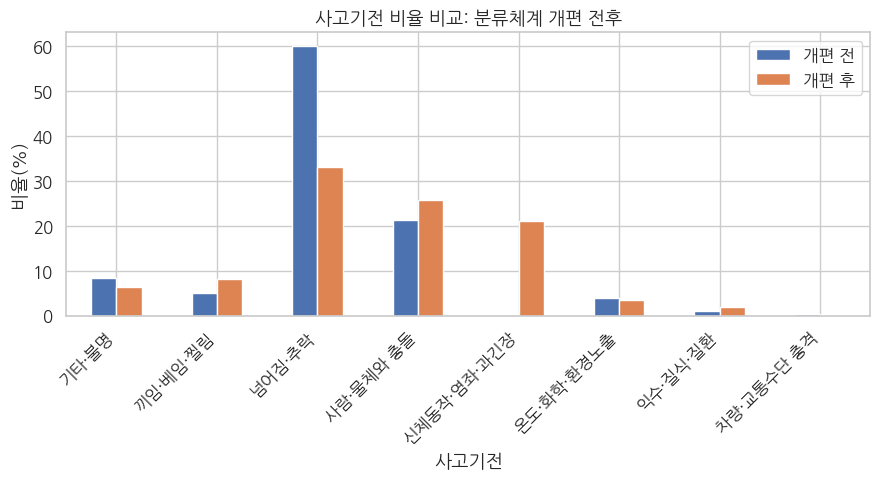

In [7]:
# 개편 이전 vs 이후(2023-2025) 사고기전 비율 비교
acc_main['시기구분'] = acc_main['사고연도'].apply(lambda y: '개편 전' if y <= 2022 else '개편 후')

mechanism_by_period = pd.crosstab(
    acc_main['사고기전'], acc_main['시기구분'], normalize='columns'
) * 100

mechanism_by_period = mechanism_by_period.round(2)
display(mechanism_by_period)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 5))
mechanism_by_period.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('비율(%)')
ax.set_title('사고기전 비율 비교: 분류체계 개편 전후')
ax.legend(title='')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# 2023~2025년 데이터 필터링
acc_main = acc_main[acc_main['사고연도'].isin([2023, 2024, 2025])].reset_index(drop=True)
comp_main = comp_main[comp_main['지급연도'].isin([2023, 2024, 2025])].reset_index(drop=True)

print(f"필터링 후: acc_main {acc_main.shape}, comp_main {comp_main.shape}")

필터링 후: acc_main (7349, 18), comp_main (5165, 17)


## 컬럼 정리

- 지역, 사고자성별, 사고자학년 삭제

In [9]:
drop_cols_acc = [c for c in ['지역', '사고자성별', '사고자학년'] if c in acc_main.columns]
drop_cols_comp = [c for c in ['지역', '사고자성별', '사고자학년'] if c in comp_main.columns]

acc_main = acc_main.drop(columns=drop_cols_acc)
comp_main = comp_main.drop(columns=drop_cols_comp)

print(f"acc_main: {acc_main.shape}")
print(f"comp_main: {comp_main.shape}")
print()
print("acc_main 컬럼:", acc_main.columns.tolist())
print("comp_main 컬럼:", comp_main.columns.tolist())

acc_main: (7349, 15)
comp_main: (5165, 14)

acc_main 컬럼: ['학교급', '사고자구분', '사고연월', '사고발생시각', '사고요일', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '접수연도', '사고연월_파싱', '사고연도', '사고기전', '시기구분']
comp_main 컬럼: ['학교급', '사고자구분', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '요양급여', '장해급여', '간병급여', '유족급여', '장례비', '지급연도', '총보상금']


## 사고기전 매핑

- 사고형태 기준
- 고용노동부 재해발생형태 분류체계 기반

In [10]:
accident_mechanism_map = {
    '넘어짐': '넘어짐·추락',
    '1미터 미만의 높이에서 떨어짐': '넘어짐·추락',
    '1미터 이상의 높이에서 떨어짐': '넘어짐·추락',
    '움직이는 물체와의 부딪힘': '사람·물체와 충돌',
    '고정된 물체와의 부딪힘': '사람·물체와 충돌',
    '사람과의 부딪힘': '사람·물체와 충돌',
    '교통사고': '차량·교통수단 충격',
    '이동 중 충격을 가함': '신체동작·염좌·과긴장',
    '스포츠 활동 중 충격을 가함': '신체동작·염좌·과긴장',
    '물건을 운반하는 중 충격을 가함': '신체동작·염좌·과긴장',
    '물체 사이에 끼임·눌림': '끼임·베임·찔림',
    '사람 사이에 끼임·눌림': '끼임·베임·찔림',
    '긁힘, 찔림': '끼임·베임·찔림',
    '베임, 절단': '끼임·베임·찔림',
    '동물에게 물림(사람 포함)': '온도·화학·환경노출',
    '곤충·식물 등에 쏘임': '온도·화학·환경노출',
    '고온의 물체·물질 접촉·흡입·섭취': '온도·화학·환경노출',
    '일사병, 열사병': '온도·화학·환경노출',
    '추위에 장시간 노출': '온도·화학·환경노출',
    '저온의 물체(드라이아이스 등)·물질 접촉': '온도·화학·환경노출',
    '화학물질 접촉·흡입·섭취': '온도·화학·환경노출',
    '이물질 접촉에 의한 피부염': '온도·화학·환경노출',
    '기타 호흡 곤란': '익수·질식·질환',
    '식중독': '익수·질식·질환',
    '이물질 섭취로 인한 질병': '익수·질식·질환',
    '이물질에 의한 질식': '익수·질식·질환',
    '그밖의 손상 사고': '기타·불명',
}

acc_main['사고기전'] = acc_main['사고형태'].map(accident_mechanism_map)
comp_main['사고기전'] = comp_main['사고형태'].map(accident_mechanism_map)

print(acc_main['사고기전'].isnull().sum(), "건 매핑 안 됨")
print(acc_main['사고기전'].value_counts())

0 건 매핑 안 됨
사고기전
넘어짐·추락         2430
사람·물체와 충돌      1897
신체동작·염좌·과긴장    1551
끼임·베임·찔림        601
기타·불명           460
온도·화학·환경노출      262
익수·질식·질환        138
차량·교통수단 충격       10
Name: count, dtype: int64


## 사고상황 매핑

### 1순위 - 사고당시활동

In [11]:
# 1순위: 사고당시활동만으로 판정 가능한 값들
situation_map_primary = {
    # 교통수단 이동·승하차
    '(교통수단 등) 운전, 조작, 탑승 중': '교통수단 이동·승하차',

    # 관람·학습체험
    '수업': '관람·학습체험',
    '자습': '관람·학습체험',
    '과학실험': '관람·학습체험',
    '일반실습': '관람·학습체험',

    # 스포츠·놀이
    '축구': '스포츠·놀이', '농구': '스포츠·놀이', '배구': '스포츠·놀이',
    '야구': '스포츠·놀이', '피구': '스포츠·놀이', '족구': '스포츠·놀이',
    '배드민턴': '스포츠·놀이', '테니스': '스포츠·놀이', '탁구': '스포츠·놀이',
    '골프': '스포츠·놀이', '볼링': '스포츠·놀이', '양궁·사격': '스포츠·놀이',
    '인라인/롤러 스케이트': '스포츠·놀이', '스케이트 보드': '스포츠·놀이',
    '사이클': '스포츠·놀이', '기타 바퀴달린 무동력 스포츠': '스포츠·놀이',
    '달리기': '스포츠·놀이', '뜀뛰기': '스포츠·놀이', '던지기': '스포츠·놀이',
    '태권도·유도·합기도': '스포츠·놀이', '검도·펜싱': '스포츠·놀이',
    '레슬링': '스포츠·놀이', '씨름': '스포츠·놀이', '복싱·킥복싱': '스포츠·놀이',
    '리듬·기계체조': '스포츠·놀이', '매트운동': '스포츠·놀이',
    '무용(댄스 포함)': '스포츠·놀이', '기타 스포츠 활동': '스포츠·놀이',
    '장난, 놀이': '스포츠·놀이',
    '기타 육상': '스포츠·놀이', '기타 구기': '스포츠·놀이', '장애물': '스포츠·놀이',
    '기타 타겟형 스포츠': '스포츠·놀이', '태권도, 유도, 합기도': '스포츠·놀이',
    '뉴스포츠(구기)': '스포츠·놀이', '기타 무도': '스포츠·놀이',
    '뉴스포츠(타켓형)': '스포츠·놀이', '기타 라켓 스포츠': '스포츠·놀이',
    '뉴스포츠(던지기)': '스포츠·놀이',

    # 자연·수상·전문활동
    '전공실습': '자연·수상·전문활동', '수영': '자연·수상·전문활동',
    '다이빙': '자연·수상·전문활동', '기타 수중 스포츠': '자연·수상·전문활동',
    '스키·스노우보드': '자연·수상·전문활동', '스케이트': '자연·수상·전문활동',
    '아이스하키': '자연·수상·전문활동', '기타 설상·빙상': '자연·수상·전문활동',
    '기타 설상, 빙상': '자연·수상·전문활동',

    # 식사·숙박·생활
    '식사': '식사·숙박·생활', '씻기': '식사·숙박·생활', '수면': '식사·숙박·생활',

    # 기타·불명
    '싸움': '기타·불명','기타': '기타·불명',
    '기타 일상활동': '기타·불명',
}

acc_main['사고상황'] = acc_main['사고당시활동'].map(situation_map_primary)

print("1차 매핑 후 미매핑 건수:", acc_main['사고상황'].isnull().sum())
print(acc_main[acc_main['사고상황'].isnull()]['사고당시활동'].value_counts())

1차 매핑 후 미매핑 건수: 2447
사고당시활동
걷기/뛰기, 오르내리기    1924
휴식               523
Name: count, dtype: int64


### 2순위 - 사고장소

In [12]:
# 2순위: 사고당시활동이 모호한 경우(휴식·걷기·기타·기타일상), 사고장소로 판정
# * 청소년 수련 시설은 장소명만으로 활동 성격이 특정되지 않는 복합공간
location_to_situation = {
    # 집결·대기
    '계단': '집결·대기', '기타 교내': '집결·대기', '기타 공용공간': '집결·대기',
    '현관': '집결·대기', '복도': '집결·대기',

    # 교통수단 이동·승하차
    '교통구역(스쿨존 외)-인도': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-인도': '교통수단 이동·승하차',
    '교통구역(스쿨존 외)-기타 교통구역': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-기타 교통구역': '교통수단 이동·승하차',
    '교통구역(스쿨존 외)-교통수단 안': '교통수단 이동·승하차',
    '교통구역(스쿨존 외)-차도': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-교통수단 안': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-차도': '교통수단 이동·승하차',
    '교통구역(스쿨존 외)-자전거도로': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-자전거도로': '교통수단 이동·승하차',

    # 관람·학습체험
    '전시관, 체험관': '관람·학습체험', '문화유적지': '관람·학습체험',
    '영화관, 공연장': '관람·학습체험', '학습지원공간': '관람·학습체험',
    '일반(교과)교실': '관람·학습체험', '특별교실(과학실 외)': '관람·학습체험',

    # 스포츠·놀이
    '공원, 유원 시설': '스포츠·놀이', '어린이 놀이시설': '스포츠·놀이',
    '기타 문화·체육공간': '스포츠·놀이', '실·내외 체육시설': '스포츠·놀이',
    '운동장': '스포츠·놀이', '강당(체육관)': '스포츠·놀이',
    '기타 체육·집회공간': '스포츠·놀이', '놀이터': '스포츠·놀이',
    '청소년 수련 시설': '스포츠·놀이',

    # 자연·수상·전문활동
    '산림·계곡': '자연·수상·전문활동', '기타 자연': '자연·수상·전문활동',
    '강·바다·하천': '자연·수상·전문활동', '현장실습/근로지(직업계고)': '자연·수상·전문활동',

    # 식사·숙박·생활
    '숙박시설/식당': '식사·숙박·생활', '화장실': '식사·숙박·생활',

    # 기타·불명
    '기타 교외': '기타·불명',
    '청소년 수련 시설': '기타·불명',
}

mask_unmapped = acc_main['사고상황'].isnull()
acc_main.loc[mask_unmapped, '사고상황'] = acc_main.loc[mask_unmapped, '사고장소'].map(location_to_situation)

print("2차 매핑 후 남은 미매핑 건수:", acc_main['사고상황'].isnull().sum())
print(acc_main[acc_main['사고상황'].isnull()]['사고장소'].value_counts())
print(acc_main['사고상황'].value_counts())

2차 매핑 후 남은 미매핑 건수: 0
Series([], Name: count, dtype: int64)
사고상황
스포츠·놀이         2916
기타·불명          1746
자연·수상·전문활동      930
관람·학습체험         657
식사·숙박·생활        582
교통수단 이동·승하차     468
집결·대기            50
Name: count, dtype: int64


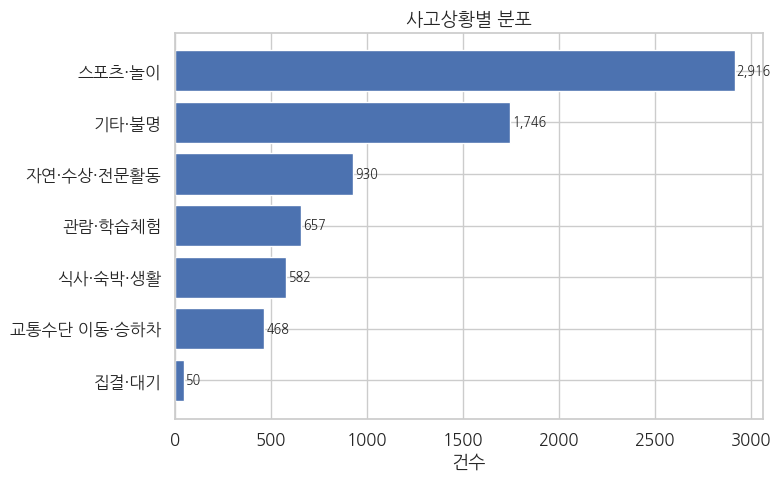

In [13]:
# 사고상황별 분포
fig, ax = plt.subplots(figsize=(8, 5))
situation_counts = acc_main['사고상황'].value_counts()
ax.barh(situation_counts.index, situation_counts.values, color='#4C72B0')
ax.invert_yaxis()
ax.set_xlabel('건수')
ax.set_title('사고상황별 분포')

for i, v in enumerate(situation_counts.values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### [참고] 기타·불명 분해 시도 - 사고발생시각

- 사고장소가 '청소년 수련시설'인 사고를 세분화해보려하였으나, 유의미한 결과 확인 X

In [14]:
# 기타·불명으로 들어간 것들이 어떤 경로로 들어왔는지 분해
etc_cases = acc_main[acc_main['사고상황'] == '기타·불명']

print("경로별 구성")
print(etc_cases['사고당시활동'].value_counts())
print()
print("경로별 사고장소")
print(etc_cases[etc_cases['사고당시활동'].isin(['걷기/뛰기, 오르내리기', '휴식'])]['사고장소'].value_counts())

경로별 구성
사고당시활동
기타              923
걷기/뛰기, 오르내리기    342
기타 일상활동         277
휴식              202
싸움                2
Name: count, dtype: int64

경로별 사고장소
사고장소
청소년 수련 시설    385
기타 교외        159
Name: count, dtype: int64


In [15]:
# 사고발생시각 타입 변환
def parse_hour(time_str):
    try:
        hour = int(str(time_str).split(':')[0])
        if 0 <= hour <= 23:
            return hour
        else:
            return None
    except (ValueError, AttributeError):
        return None

acc_main['사고발생시_숫자'] = acc_main['사고발생시각'].apply(parse_hour)

print("파싱 실패(결측 포함) 건수:", acc_main['사고발생시_숫자'].isnull().sum())
print(acc_main['사고발생시_숫자'].describe())

파싱 실패(결측 포함) 건수: 0
count    7349.000000
mean       13.094435
std         3.716668
min         0.000000
25%        11.000000
50%        12.000000
75%        15.000000
max        23.000000
Name: 사고발생시_숫자, dtype: float64


시간대
오후(12-17시)    155
저녁(18-23시)    129
오전(6-11시)      92
새벽(0-5시)        9
Name: count, dtype: int64


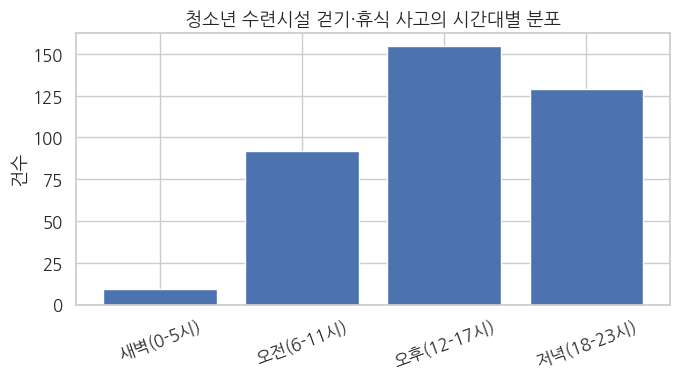

In [16]:
# 시간대 구간화
youth_ambiguous = acc_main[
    (acc_main['사고장소'] == '청소년 수련 시설') &
    (acc_main['사고당시활동'].isin(['걷기/뛰기, 오르내리기', '휴식']))
].copy()

youth_ambiguous['시간대'] = pd.cut(
    youth_ambiguous['사고발생시_숫자'],
    bins=[-1, 5, 11, 17, 23],
    labels=['새벽(0-5시)', '오전(6-11시)', '오후(12-17시)', '저녁(18-23시)']
)

print(youth_ambiguous['시간대'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
time_counts = youth_ambiguous['시간대'].value_counts().sort_index()
ax.bar(time_counts.index.astype(str), time_counts.values, color='#4C72B0')
ax.set_title('청소년 수련시설 걷기·휴식 사고의 시간대별 분포')
ax.set_ylabel('건수')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [17]:
# 청소년 수련 시설 교차표
cross_time_activity = pd.crosstab(youth_ambiguous['시간대'], youth_ambiguous['사고당시활동'])
display(cross_time_activity)

사고당시활동,"걷기/뛰기, 오르내리기",휴식
시간대,,
새벽(0-5시),1,8
오전(6-11시),63,29
오후(12-17시),91,64
저녁(18-23시),49,80


### comp_main 매핑

In [18]:
# comp_main에 사고기전 매핑
comp_main['사고기전'] = comp_main['사고형태'].map(accident_mechanism_map)

# comp_main에 사고상황 매핑
comp_main['사고상황'] = comp_main['사고당시활동'].map(situation_map_primary)

mask_unmapped_comp = comp_main['사고상황'].isnull()
comp_main.loc[mask_unmapped_comp, '사고상황'] = comp_main.loc[mask_unmapped_comp, '사고장소'].map(location_to_situation)

comp_main['사고상황'] = comp_main['사고상황'].fillna('기타·불명')

print("acc_main 사고기전 미매핑:", acc_main['사고기전'].isnull().sum())
print("comp_main 사고기전 미매핑:", comp_main['사고기전'].isnull().sum())
print()
print("comp_main 사고기전 분포")
print(comp_main['사고기전'].value_counts())
print("comp_main 사고상황 분포")
print(comp_main['사고상황'].value_counts())

acc_main 사고기전 미매핑: 0
comp_main 사고기전 미매핑: 0

comp_main 사고기전 분포
사고기전
넘어짐·추락         1936
사람·물체와 충돌      1278
신체동작·염좌·과긴장    1001
끼임·베임·찔림        390
기타·불명           329
온도·화학·환경노출      167
익수·질식·질환         61
차량·교통수단 충격        3
Name: count, dtype: int64
comp_main 사고상황 분포
사고상황
스포츠·놀이         2002
기타·불명          1317
자연·수상·전문활동      662
관람·학습체험         440
식사·숙박·생활        374
교통수단 이동·승하차     333
집결·대기            37
Name: count, dtype: int64


## 최종 세그먼트 결합 - 사고상황 × 사고기전

In [19]:
acc_main['세그먼트'] = acc_main['사고상황'] + ' × ' + acc_main['사고기전']
comp_main['세그먼트'] = comp_main['사고상황'] + ' × ' + comp_main['사고기전']

print("2차원 세그먼트 종류 수:", acc_main['세그먼트'].nunique())
print(acc_main['세그먼트'].value_counts())

2차원 세그먼트 종류 수: 49
세그먼트
스포츠·놀이 × 넘어짐·추락              960
스포츠·놀이 × 사람·물체와 충돌           866
스포츠·놀이 × 신체동작·염좌·과긴장         752
기타·불명 × 넘어짐·추락               476
기타·불명 × 사람·물체와 충돌            460
자연·수상·전문활동 × 넘어짐·추락          410
기타·불명 × 신체동작·염좌·과긴장          275
관람·학습체험 × 넘어짐·추락             239
자연·수상·전문활동 × 신체동작·염좌·과긴장     237
기타·불명 × 기타·불명                193
스포츠·놀이 × 끼임·베임·찔림            186
교통수단 이동·승하차 × 넘어짐·추락         186
기타·불명 × 끼임·베임·찔림             166
자연·수상·전문활동 × 사람·물체와 충돌       160
식사·숙박·생활 × 사람·물체와 충돌         156
관람·학습체험 × 사람·물체와 충돌          152
식사·숙박·생활 × 넘어짐·추락            136
관람·학습체험 × 신체동작·염좌·과긴장        123
스포츠·놀이 × 기타·불명               104
기타·불명 × 익수·질식·질환              93
교통수단 이동·승하차 × 사람·물체와 충돌       93
교통수단 이동·승하차 × 신체동작·염좌·과긴장     86
기타·불명 × 온도·화학·환경노출            83
식사·숙박·생활 × 끼임·베임·찔림           81
관람·학습체험 × 끼임·베임·찔림            69
식사·숙박·생활 × 신체동작·염좌·과긴장        66
식사·숙박·생활 × 온도·화학·환경노출         66
식사·숙박·생활 × 기타·불명              56
자연·수상·전문활동 × 끼임·베임·찔림         52
관람·학습체험 × 온도·화학·환경노출

In [20]:
# 세그먼트별 표본 크기만 확인
segment_acc_count = acc_main.groupby('세그먼트').size().reset_index(name='사고건수')
segment_comp_count = comp_main.groupby('세그먼트').size().reset_index(name='보상건수')

segment_combined = segment_acc_count.merge(segment_comp_count, on='세그먼트', how='inner')
assert len(segment_combined) == len(segment_acc_count), "acc_main 기준 세그먼트 누락 발생"

def classify_reliability(n):
    if n >= 30:
        return '본분석'
    elif n >= 10:
        return '탐색적'
    else:
        return '제외'

segment_combined['신뢰도구분'] = segment_combined['보상건수'].apply(classify_reliability)
segment_main = segment_combined[segment_combined['신뢰도구분'] == '본분석'][['세그먼트', '사고건수', '보상건수']].copy()

print(f"본분석 대상: {len(segment_main)}개")

본분석 대상: 31개


In [21]:
# [참고] 보상데이터에만 있고 사고데이터에는 없는 세그먼트
comp_segments = set(comp_main['세그먼트'].unique())
acc_segments = set(acc_main['세그먼트'].unique())

only_in_comp = comp_segments - acc_segments
print("comp_main에만 있고 acc_main에는 없는 세그먼트:", only_in_comp)

comp_main에만 있고 acc_main에는 없는 세그먼트: {'기타·불명 × 차량·교통수단 충격'}


In [22]:
segment_combined = segment_acc_count.merge(segment_comp_count, on='세그먼트', how='inner')

# inner join 기준: acc_main(사고건수)이 기준 축이므로 combined는 acc_count와 같아야 함
assert len(segment_combined) == len(segment_acc_count), \
    f"acc_main 기준 세그먼트가 누락됨: acc={len(segment_acc_count)}, combined={len(segment_combined)}"

dropped = len(segment_comp_count) - len(segment_combined)
print(f"comp_main에만 있어 분석에서 제외된 세그먼트: {dropped}개")

def classify_reliability(n):
    if n >= 30:
        return '본분석'
    elif n >= 10:
        return '탐색적'
    else:
        return '제외'

segment_combined['신뢰도구분'] = segment_combined['보상건수'].apply(classify_reliability)

segment_main = segment_combined[segment_combined['신뢰도구분'] == '본분석'].copy()
segment_exploratory = segment_combined[segment_combined['신뢰도구분'] == '탐색적'].copy()

total_accidents = segment_combined['사고건수'].sum()
main_accidents = segment_main['사고건수'].sum()

print(f"본분석 대상 세그먼트: {len(segment_main)}개")
print(f"탐색적 대상 세그먼트: {len(segment_exploratory)}개")
print(f"제외된 세그먼트: {len(segment_combined) - len(segment_main) - len(segment_exploratory)}개")
print(f"본분석 대상 사고건수 포괄률: {main_accidents/total_accidents*100:.1f}%")

comp_main에만 있어 분석에서 제외된 세그먼트: 1개
본분석 대상 세그먼트: 31개
탐색적 대상 세그먼트: 6개
제외된 세그먼트: 12개
본분석 대상 사고건수 포괄률: 96.4%


In [23]:
display(segment_main)

,세그먼트,사고건수,보상건수,신뢰도구분
1,관람·학습체험 × 끼임·베임·찔림,69,41,본분석
2,관람·학습체험 × 넘어짐·추락,239,165,본분석
3,관람·학습체험 × 사람·물체와 충돌,152,88,본분석
4,관람·학습체험 × 신체동작·염좌·과긴장,123,87,본분석
5,관람·학습체험 × 온도·화학·환경노출,50,37,본분석
9,교통수단 이동·승하차 × 넘어짐·추락,186,143,본분석
10,교통수단 이동·승하차 × 사람·물체와 충돌,93,69,본분석
11,교통수단 이동·승하차 × 신체동작·염좌·과긴장,86,67,본분석
15,기타·불명 × 기타·불명,193,149,본분석
16,기타·불명 × 끼임·베임·찔림,166,115,본분석


## 발생비중 (F) 계산

- 발생비중 = 해당 세그먼트 사고건수 / 전체 사고건수 * 100

In [24]:
from scipy.stats import skew

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [25]:
# [참고] 로그변환 필요성
segment_main['건수_log'] = np.log1p(segment_main['사고건수'])

raw_skew = skew(segment_main['사고건수'])
log_skew = skew(segment_main['건수_log'])

print(f"원본 사고건수 왜도: {raw_skew:.2f}")
print(f"로그변환 후 왜도: {log_skew:.2f}")

원본 사고건수 왜도: 1.90
로그변환 후 왜도: 0.62


In [26]:
# [참고] 세그먼트별 사고건수 추세 확인
year_counts = acc_main.groupby(['세그먼트', '사고연도']).size().unstack(fill_value=0)
year_counts = year_counts.reindex(segment_main['세그먼트'])

# 두 구간의 증감 방향 확인
change_1 = year_counts[2024] - year_counts[2023]
change_2 = year_counts[2025] - year_counts[2024]

def classify_trend(c1, c2):
    if c1 > 0 and c2 > 0:
        return '꾸준히 증가'
    elif c1 < 0 and c2 < 0:
        return '꾸준히 감소'
    elif c1 == 0 and c2 == 0:
        return '변화 없음'
    else:
        return '들쭉날쭉'

trend = pd.DataFrame({
    '세그먼트': year_counts.index,
    '2023': year_counts[2023].values,
    '2024': year_counts[2024].values,
    '2025': year_counts[2025].values,
    '구간1_변화': change_1.values,
    '구간2_변화': change_2.values,
})
trend['추세'] = trend.apply(lambda row: classify_trend(row['구간1_변화'], row['구간2_변화']), axis=1)

print(trend['추세'].value_counts())
print()
display(trend.sort_values('사고건수' if '사고건수' in trend.columns else '2025', ascending=False))

추세
들쭉날쭉      20
꾸준히 감소    10
꾸준히 증가     1
Name: count, dtype: int64



,세그먼트,2023,2024,2025,구간1_변화,구간2_변화,추세
17,스포츠·놀이 × 넘어짐·추락,355,329,276,-26,-53,꾸준히 감소
18,스포츠·놀이 × 사람·물체와 충돌,271,330,265,59,-65,들쭉날쭉
19,스포츠·놀이 × 신체동작·염좌·과긴장,260,248,244,-12,-4,꾸준히 감소
10,기타·불명 × 넘어짐·추락,156,179,141,23,-38,들쭉날쭉
11,기타·불명 × 사람·물체와 충돌,153,168,139,15,-29,들쭉날쭉
28,자연·수상·전문활동 × 넘어짐·추락,155,136,119,-19,-17,꾸준히 감소
12,기타·불명 × 신체동작·염좌·과긴장,96,94,85,-2,-9,꾸준히 감소
14,기타·불명 × 익수·질식·질환,8,2,83,-6,81,들쭉날쭉
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,79,81,77,2,-4,들쭉날쭉
16,스포츠·놀이 × 끼임·베임·찔림,63,56,67,-7,11,들쭉날쭉


In [27]:
# [참고] 세그먼트별 사고건수 추세 비율
print("추세 분포가 한쪽으로 쏠려있지 않은지 확인")
print(trend['추세'].value_counts(normalize=True).round(3) * 100, "%")

추세 분포가 한쪽으로 쏠려있지 않은지 확인
추세
들쭉날쭉      64.5
꾸준히 감소    32.3
꾸준히 증가     3.2
Name: proportion, dtype: float64 %


In [28]:
# 발생비중 계산
total_all_segments = acc_main['세그먼트'].value_counts().sum()
segment_main['발생비중'] = (segment_main['사고건수'] / total_all_segments * 100).round(2)

display(segment_main[['세그먼트', '사고건수', '발생비중']].sort_values('발생비중', ascending=False))

,세그먼트,사고건수,발생비중
24,스포츠·놀이 × 넘어짐·추락,960,13.06
25,스포츠·놀이 × 사람·물체와 충돌,866,11.78
26,스포츠·놀이 × 신체동작·염좌·과긴장,752,10.23
17,기타·불명 × 넘어짐·추락,476,6.48
18,기타·불명 × 사람·물체와 충돌,460,6.26
39,자연·수상·전문활동 × 넘어짐·추락,410,5.58
19,기타·불명 × 신체동작·염좌·과긴장,275,3.74
2,관람·학습체험 × 넘어짐·추락,239,3.25
41,자연·수상·전문활동 × 신체동작·염좌·과긴장,237,3.22
15,기타·불명 × 기타·불명,193,2.63


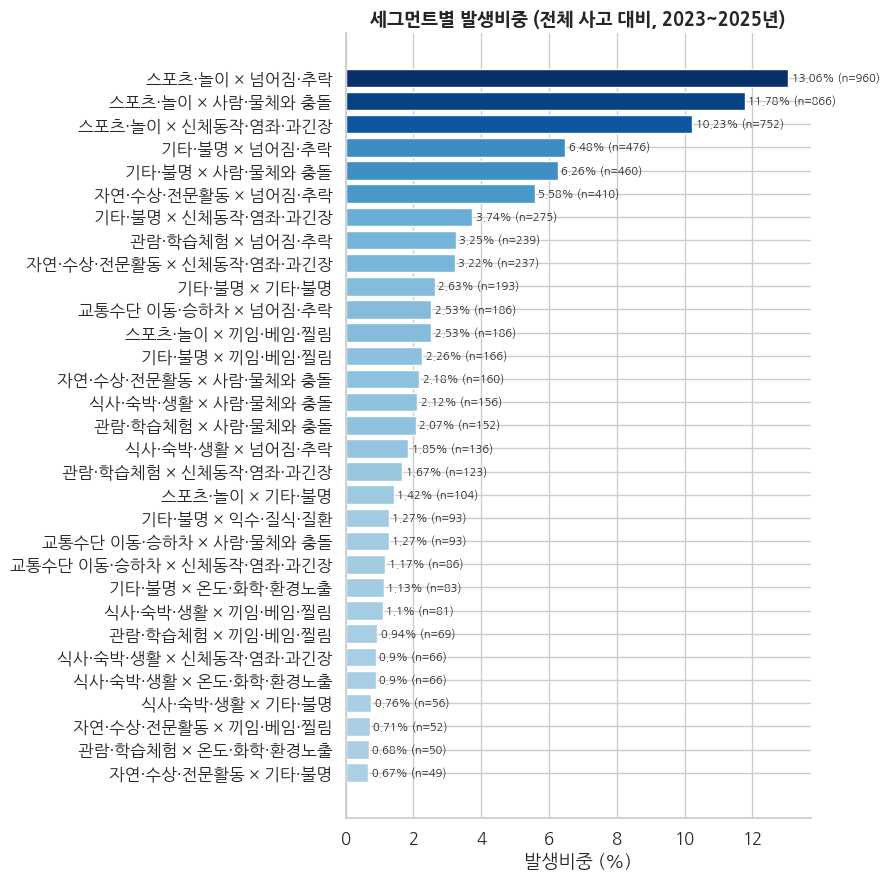

In [29]:
# 세그먼트별 발생비중 그래프
fig, ax = plt.subplots(figsize=(9, 9))

plot_data = segment_main.sort_values('발생비중')
colors = plt.cm.Blues(plot_data['발생비중'] / plot_data['발생비중'].max() * 0.7 + 0.3)

bars = ax.barh(plot_data['세그먼트'], plot_data['발생비중'], color=colors)
ax.set_xlabel('발생비중 (%)')
ax.set_title('세그먼트별 발생비중 (전체 사고 대비, 2023~2025년)', fontsize=13, fontweight='bold')

for i, (pct, count) in enumerate(zip(plot_data['발생비중'], plot_data['사고건수'])):
    ax.text(pct + 0.1, i, f'{pct}% (n={count})', va='center', fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [30]:
# [참고] 세그먼트별 연도별 건수 표
year_breakdown = acc_main.groupby(['세그먼트', '사고연도']).size().unstack(fill_value=0)
year_breakdown.columns = [f'{y}년' for y in year_breakdown.columns]

segment_main = segment_main.merge(year_breakdown, on='세그먼트', how='left')

display(
    segment_main[['세그먼트', '발생비중', '2023년', '2024년', '2025년']]
    .sort_values('발생비중', ascending=False)
)

,세그먼트,발생비중,2023년,2024년,2025년
17,스포츠·놀이 × 넘어짐·추락,13.06,355,329,276
18,스포츠·놀이 × 사람·물체와 충돌,11.78,271,330,265
19,스포츠·놀이 × 신체동작·염좌·과긴장,10.23,260,248,244
10,기타·불명 × 넘어짐·추락,6.48,156,179,141
11,기타·불명 × 사람·물체와 충돌,6.26,153,168,139
28,자연·수상·전문활동 × 넘어짐·추락,5.58,155,136,119
12,기타·불명 × 신체동작·염좌·과긴장,3.74,96,94,85
1,관람·학습체험 × 넘어짐·추락,3.25,85,91,63
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,3.22,79,81,77
8,기타·불명 × 기타·불명,2.63,60,70,63


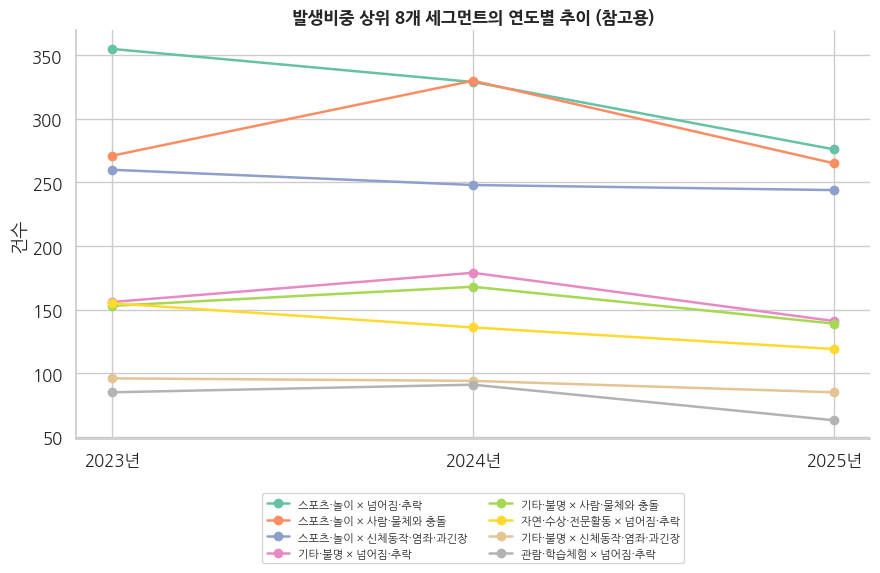

In [31]:
# [참고] 연도별 추이 그래프 TOP 8
top8 = segment_main.nlargest(8, '발생비중')

fig, ax = plt.subplots(figsize=(9, 6))
years = ['2023년', '2024년', '2025년']

for _, row in top8.iterrows():
    ax.plot(years, row[years].values, marker='o', label=row['세그먼트'], linewidth=1.8)

ax.set_ylabel('건수')
ax.set_title('발생비중 상위 8개 세그먼트의 연도별 추이 (참고용)', fontsize=12, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 조건부심각도 (S) 계산

- 로그변환 + 경험적 베이즈 보정(혼합효과모형) + 평균대비배수

In [32]:
import statsmodels.formula.api as smf
from scipy.stats import skew, f_oneway, spearmanr

In [33]:
# [기각] 이진 임계값 방식 (500만원 이상 여부 - 공식 통계 기준)
# 본분석 31개 세그먼트 중 16개가 0건 — 세그먼트 간 비교 불가능한 수준
comp_main['고비용여부_500만'] = comp_main['총보상금'] >= 5_000_000

check_500 = (
    comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])]
    .groupby('세그먼트')['고비용여부_500만']
    .sum()
)
print(f"고비용건수 0건인 세그먼트: {(check_500 == 0).sum()} / {len(check_500)}개")

고비용건수 0건인 세그먼트: 16 / 31개


In [34]:
# [기각] 급여 유형 기반 4단계 등급 + 가중치(10/5/3/1)
# Level 2/3 대부분 급여 유형이 아닌 금액만으로 배정
# 상위 2% 구간의 85.6%가 급여 유형과 무관하게 순수 금액만으로 도달
def classify_severity_level(row):
    if row['유족급여'] > 0 or row['장례비'] > 0:
        return 'Level4_치명'
    elif row['장해급여'] > 0 or row['총보상금'] >= 5_000_000:
        return 'Level3_중상장해'
    elif row['간병급여'] > 0 or row['총보상금'] >= 1_000_000:
        return 'Level2_중등도'
    else:
        return 'Level1_경미'

comp_main['심각도등급'] = comp_main.apply(classify_severity_level, axis=1)
print(comp_main['심각도등급'].value_counts())
print()

# 등급이 급여 유형 때문인지, 금액 때문인지 분해 확인
level2_cases = comp_main[comp_main['심각도등급'] == 'Level2_중등도']
level3_cases = comp_main[comp_main['심각도등급'] == 'Level3_중상장해']

print("Level2 중 금액만으로 배정:",
      ((level2_cases['간병급여'] == 0) & (level2_cases['총보상금'] >= 1_000_000)).sum(), "/", len(level2_cases))
print("Level3 중 금액만으로 배정:",
      ((level3_cases['장해급여'] == 0) & (level3_cases['총보상금'] >= 5_000_000)).sum(), "/", len(level3_cases))
print()

# 급여 유형별로 총보상금 백분위 위치 확인 (금액과 독립적인 정보가 있는지)
comp_main['보상금_백분위'] = comp_main['총보상금'].rank(pct=True) * 100

for col, name in [('간병급여', '간병'), ('장해급여', '장해')]:
    cases = comp_main[comp_main[col] > 0]
    print(f"{name}급여 발생 건 (n={len(cases)}): 백분위 범위 {cases['보상금_백분위'].min():.1f} ~ {cases['보상금_백분위'].max():.1f}")

death_cases = comp_main[(comp_main['유족급여'] > 0) | (comp_main['장례비'] > 0)]
print(f"사망 발생 건 (n={len(death_cases)}): 백분위 범위 {death_cases['보상금_백분위'].min():.1f} ~ {death_cases['보상금_백분위'].max():.1f}")
print()

# 상위 2% 구간에서 급여 유형 구성 확인
comp_main_sorted = comp_main.sort_values('보상금_백분위', ascending=False)
top_2pct = comp_main_sorted[comp_main_sorted['보상금_백분위'] >= 98].copy()

def get_dominant_benefit(row):
    if row['유족급여'] > 0 or row['장례비'] > 0:
        return '사망'
    elif row['장해급여'] > 0:
        return '장해'
    elif row['간병급여'] > 0:
        return '간병'
    else:
        return '요양급여만'

top_2pct['주요급여유형'] = top_2pct.apply(get_dominant_benefit, axis=1)
print(top_2pct['주요급여유형'].value_counts())

심각도등급
Level1_경미      4677
Level2_중등도      452
Level3_중상장해      31
Level4_치명         5
Name: count, dtype: int64

Level2 중 금액만으로 배정: 451 / 452
Level3 중 금액만으로 배정: 23 / 31

간병급여 발생 건 (n=2): 백분위 범위 98.7 ~ 99.5
장해급여 발생 건 (n=8): 백분위 범위 99.7 ~ 100.0
사망 발생 건 (n=5): 백분위 범위 99.9 ~ 100.0

주요급여유형
요양급여만    89
장해        8
사망        5
간병        2
Name: count, dtype: int64


In [35]:
# 1) 개별 사고 단위 로그변환
comp_main['보상금_log'] = np.log1p(comp_main['총보상금'])
print(f"원본 왜도: {skew(comp_main['총보상금']):.2f} → 로그변환 후: {skew(comp_main['보상금_log']):.2f}")

원본 왜도: 32.71 → 로그변환 후: 0.55


In [36]:
# 2) 혼합효과모형으로 경험적 베이즈 사전강도(prior strength) 산출
target_data = comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])].copy()

mixedlm_model = smf.mixedlm("보상금_log ~ 1", data=target_data, groups=target_data['세그먼트'])
mixedlm_result = mixedlm_model.fit()

prior_strength = mixedlm_result.scale / mixedlm_result.cov_re.iloc[0, 0]
print(f"세그먼트 간 분산: {mixedlm_result.cov_re.iloc[0, 0]:.4f} / 세그먼트 내 분산: {mixedlm_result.scale:.4f}")
print(f"경험적 베이즈 사전강도: {prior_strength:.2f}")

세그먼트 간 분산: 0.0822 / 세그먼트 내 분산: 1.8268
경험적 베이즈 사전강도: 22.22


In [37]:
# 3) 세그먼트별 평균 로그값 산출 + 경험적 베이즈 보정
# 공식: 보정평균 = (세그먼트평균×n + 전체평균×사전강도) / (n + 사전강도)
# n이 클수록 세그먼트 자체 평균에, n이 작을수록 전체평균 쪽으로 수렴
# 세그먼트별 평균(일반 사고 기준) 산출 및 경험적 베이즈 보정
segment_severity_log = (
    comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])]
    .groupby('세그먼트')['보상금_log']
    .mean()
    .reset_index(name='평균_보상금_log')
)
segment_main = segment_main.merge(segment_severity_log, on='세그먼트', how='left')

overall_mean_log = comp_main['보상금_log'].mean()

segment_main['심각도_log_보정'] = (
    (segment_main['평균_보상금_log'] * segment_main['보상건수'] +
     overall_mean_log * prior_strength) /
    (segment_main['보상건수'] + prior_strength)
)

In [38]:
# 4) 로그 공간에서 차이를 구한 뒤 지수화 -> 평균 대비 배수
log_mean = segment_main['심각도_log_보정'].mean()
segment_main['조건부심각도'] = np.exp(segment_main['심각도_log_보정'] - log_mean).round(3)

print(f"조건부심각도 범위: {segment_main['조건부심각도'].min():.3f} ~ {segment_main['조건부심각도'].max():.3f}")
display(segment_main[['세그먼트', '보상건수', '조건부심각도']].sort_values('조건부심각도', ascending=False))

조건부심각도 범위: 0.539 ~ 1.542


,세그먼트,보상건수,조건부심각도
10,기타·불명 × 넘어짐·추락,477,1.542
26,자연·수상·전문활동 × 기타·불명,30,1.403
22,식사·숙박·생활 × 넘어짐·추락,84,1.383
28,자연·수상·전문활동 × 넘어짐·추락,327,1.286
1,관람·학습체험 × 넘어짐·추락,165,1.284
25,식사·숙박·생활 × 온도·화학·환경노출,46,1.259
5,교통수단 이동·승하차 × 넘어짐·추락,143,1.205
17,스포츠·놀이 × 넘어짐·추락,723,1.191
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,149,1.190
7,교통수단 이동·승하차 × 신체동작·염좌·과긴장,67,1.125


In [39]:
# [검증] 극단값·극단결과 안정성
# ① 최고액 단일 사고 제외 시 안정성
outlier_amount = comp_main['총보상금'].max()
without_top = comp_main[comp_main['총보상금'] != outlier_amount]

recheck = (
    without_top[without_top['세그먼트'].isin(segment_main['세그먼트'])]
    .groupby('세그먼트')['보상금_log']
    .agg(평균_log_재계산='mean', 보상건수_재계산='count')
    .reset_index()
)
overall_mean_new = without_top['보상금_log'].mean()
recheck['보정_재계산'] = (
    (recheck['평균_log_재계산'] * recheck['보상건수_재계산'] + overall_mean_new * prior_strength) /
    (recheck['보상건수_재계산'] + prior_strength)
)
log_mean_new = recheck['보정_재계산'].mean()
recheck['점수_재계산'] = np.exp(recheck['보정_재계산'] - log_mean_new)

compare = segment_main[['세그먼트', '조건부심각도']].merge(recheck[['세그먼트', '점수_재계산']], on='세그먼트')
compare['변화폭'] = (compare['조건부심각도'] - compare['점수_재계산']).abs()
print(f"최고액 단일 사고 제외 시 평균 변화폭: {compare['변화폭'].mean():.4f}")

# ② 사망·후유장해(극단결과) 포함 여부가 세그먼트 순위를 흔드는지 확인
comp_main['극단결과'] = (comp_main['유족급여'] > 0) | (comp_main['장례비'] > 0) | (comp_main['장해급여'] > 0)

extreme_by_segment = (
    comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])]
    .groupby('세그먼트')['극단결과']
    .sum()
    .reset_index(name='극단결과_건수')
)
segment_main = segment_main.merge(extreme_by_segment, on='세그먼트', how='left')
segment_main['극단결과_존재'] = segment_main['극단결과_건수'] > 0

affected = segment_main[segment_main['극단결과_존재']]['세그먼트'].tolist()
max_shift = 0
for seg in affected:
    with_all = comp_main[comp_main['세그먼트'] == seg]['보상금_log'].mean()
    without_ext = comp_main[(comp_main['세그먼트'] == seg) & (~comp_main['극단결과'])]['보상금_log'].mean()
    max_shift = max(max_shift, abs(with_all - without_ext))

print(f"극단결과가 낀 {len(affected)}개 세그먼트 중 최대 변화폭(로그 스케일): {max_shift:.3f}")

최고액 단일 사고 제외 시 평균 변화폭: 0.0004
극단결과가 낀 8개 세그먼트 중 최대 변화폭(로그 스케일): 0.089


In [40]:
# [참고] 사고기전 vs 사고상황의 심각도 설명력 비교
mechanism_severity = segment_main.copy()
mechanism_severity['사고기전'] = mechanism_severity['세그먼트'].str.split(' × ').str[1]
mechanism_severity['사고상황'] = mechanism_severity['세그먼트'].str.split(' × ').str[0]

valid_mechanisms = mechanism_severity['사고기전'].value_counts()
valid_mechanisms = valid_mechanisms[valid_mechanisms >= 3].index
groups_mech = [mechanism_severity[mechanism_severity['사고기전'] == m]['조건부심각도'].values for m in valid_mechanisms]
f_mech, p_mech = f_oneway(*groups_mech)
print(f"사고기전 간 조건부심각도 차이 - ANOVA: F={f_mech:.2f}, p={p_mech:.4f}")

valid_situations = mechanism_severity['사고상황'].value_counts()
valid_situations = valid_situations[valid_situations >= 3].index
groups_sit = [mechanism_severity[mechanism_severity['사고상황'] == s]['조건부심각도'].values for s in valid_situations]
f_sit, p_sit = f_oneway(*groups_sit)
print(f"사고상황 간 조건부심각도 차이 - ANOVA: F={f_sit:.2f}, p={p_sit:.4f}")

사고기전 간 조건부심각도 차이 - ANOVA: F=5.65, p=0.0014
사고상황 간 조건부심각도 차이 - ANOVA: F=0.99, p=0.4461


## 이중위험지도

In [41]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
# !pip install adjustText
from adjustText import adjust_text

korean_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name or 'Malgun' in f.name]
plt.rcParams['font.family'] = korean_fonts[0] if korean_fonts else 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

In [42]:
# 사분면 구분: x축 기준선은 평균 발생비중, y축 기준선은 조건부심각도=1.0(평균)
x_ref = segment_main['발생비중'].mean()

def classify_quadrant(row):
    high_freq = row['발생비중'] >= x_ref
    high_severity = row['조건부심각도'] >= 1.0
    if high_freq and high_severity:
        return '복합고위험형'
    elif not high_freq and high_severity:
        return '잠복고비용형'
    elif high_freq and not high_severity:
        return '만성반복형'
    else:
        return '일반관리형'

segment_main['사분면'] = segment_main.apply(classify_quadrant, axis=1)
print(segment_main['사분면'].value_counts())

사분면
일반관리형     12
잠복고비용형    10
복합고위험형     7
만성반복형      2
Name: count, dtype: int64


In [43]:
# 극단결과(사망·후유장해) 포함 여부 플래그
comp_main['극단결과'] = (comp_main['유족급여'] > 0) | (comp_main['장례비'] > 0) | (comp_main['장해급여'] > 0)

extreme_by_segment = (
    comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])]
    .groupby('세그먼트')['극단결과']
    .sum()
    .reset_index(name='극단결과_건수')
)
segment_main = segment_main.drop(columns=['극단결과_건수', '극단결과_존재'], errors='ignore')
segment_main = segment_main.merge(extreme_by_segment, on='세그먼트', how='left')
segment_main['극단결과_존재'] = segment_main['극단결과_건수'] > 0

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


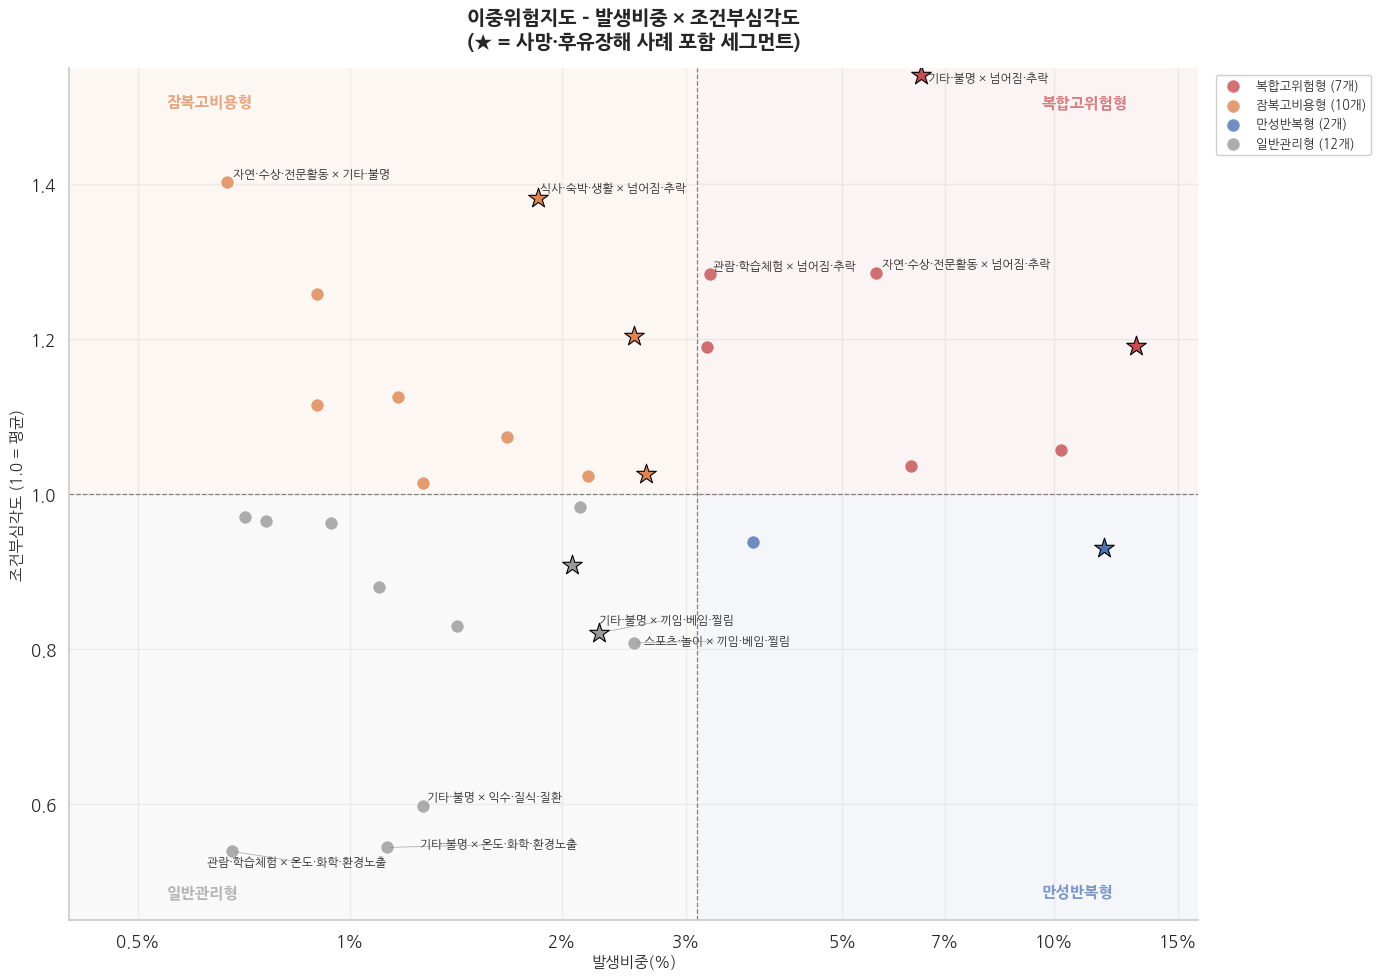

In [44]:
colors_map = {'복합고위험형': '#C44E52', '잠복고비용형': '#DD8452', '만성반복형': '#4C72B0', '일반관리형': '#999999'}

fig, ax = plt.subplots(figsize=(14, 10))

x_min, x_max = 0.4, 16
y_min, y_max = 0.45, 1.55
y_frac = (1.0 - y_min) / (y_max - y_min)  # y=1.0 지점의 축 내 상대 위치

# 사분면 배경색
ax.axvspan(x_min, x_ref, ymin=y_frac, ymax=1, facecolor='#DD8452', alpha=0.06, zorder=0)  # 잠복고비용형
ax.axvspan(x_ref, x_max, ymin=y_frac, ymax=1, facecolor='#C44E52', alpha=0.06, zorder=0)  # 복합고위험형
ax.axvspan(x_ref, x_max, ymin=0, ymax=y_frac, facecolor='#4C72B0', alpha=0.06, zorder=0)  # 만성반복형
ax.axvspan(x_min, x_ref, ymin=0, ymax=y_frac, facecolor='#999999', alpha=0.06, zorder=0)  # 일반관리형

# 점 (극단결과 없음: 원, 있음: 별)
for quadrant, color in colors_map.items():
    subset = segment_main[(segment_main['사분면'] == quadrant) & (~segment_main['극단결과_존재'])]
    ax.scatter(subset['발생비중'], subset['조건부심각도'], s=90, alpha=0.8, color=color,
               edgecolor='white', linewidth=0.6,
               label=f'{quadrant} ({(segment_main["사분면"]==quadrant).sum()}개)', zorder=3)

for quadrant, color in colors_map.items():
    subset = segment_main[(segment_main['사분면'] == quadrant) & (segment_main['극단결과_존재'])]
    ax.scatter(subset['발생비중'], subset['조건부심각도'], s=220, marker='*',
               color=color, edgecolor='black', linewidth=0.8, zorder=5)

# 축 설정
ax.set_xscale('log')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
tick_values = [0.5, 1, 2, 3, 5, 7, 10, 15]
ax.set_xticks(tick_values)
ax.set_xticklabels([f'{v}%' for v in tick_values])

ax.axvline(x_ref, color='gray', linestyle='--', linewidth=0.9, zorder=1)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.9, zorder=1)

# 사분면 이름표
ax.text(0.55, 1.5, '잠복고비용형', fontsize=11, color='#DD8452', fontweight='bold', alpha=0.7)
ax.text(x_max*0.6, 1.5, '복합고위험형', fontsize=11, color='#C44E52', fontweight='bold', alpha=0.7)
ax.text(x_max*0.6, 0.48, '만성반복형', fontsize=11, color='#4C72B0', fontweight='bold', alpha=0.7)
ax.text(0.55, 0.48, '일반관리형', fontsize=11, color='#999999', fontweight='bold', alpha=0.7)

# 라벨 - 상하위 15%만
label_targets = segment_main[
    (segment_main['조건부심각도'] >= segment_main['조건부심각도'].quantile(0.85)) |
    (segment_main['조건부심각도'] <= segment_main['조건부심각도'].quantile(0.15))
]

texts = []
for _, row in label_targets.iterrows():
    texts.append(ax.text(row['발생비중'], row['조건부심각도'], row['세그먼트'], fontsize=8.5))

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.7),
    expand_points=(1.5, 1.5)
)

# 라벨 및 스타일 마무리
ax.set_xlabel('발생비중(%)', fontsize=11)
ax.set_ylabel('조건부심각도 (1.0 = 평균)', fontsize=11)
ax.set_title('이중위험지도 - 발생비중 × 조건부심각도\n(★ = 사망·후유장해 사례 포함 세그먼트)', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, framealpha=0.95)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

In [45]:
# 사분면별 세그먼트 목록
for quadrant in ['잠복고비용형', '복합고위험형', '만성반복형', '일반관리형']:
    subset = segment_main[segment_main['사분면'] == quadrant].sort_values('조건부심각도', ascending=False)
    print(f"\n=== {quadrant} ({len(subset)}개) ===")
    display(subset[['세그먼트', '발생비중', '조건부심각도', '극단결과_존재']])


=== 잠복고비용형 (10개) ===


,세그먼트,발생비중,조건부심각도,극단결과_존재
26,자연·수상·전문활동 × 기타·불명,0.67,1.403,False
22,식사·숙박·생활 × 넘어짐·추락,1.85,1.383,True
25,식사·숙박·생활 × 온도·화학·환경노출,0.90,1.259,False
5,교통수단 이동·승하차 × 넘어짐·추락,2.53,1.205,True
7,교통수단 이동·승하차 × 신체동작·염좌·과긴장,1.17,1.125,False
24,식사·숙박·생활 × 신체동작·염좌·과긴장,0.90,1.115,False
3,관람·학습체험 × 신체동작·염좌·과긴장,1.67,1.074,False
8,기타·불명 × 기타·불명,2.63,1.026,True
29,자연·수상·전문활동 × 사람·물체와 충돌,2.18,1.024,False
6,교통수단 이동·승하차 × 사람·물체와 충돌,1.27,1.015,False



=== 복합고위험형 (7개) ===


,세그먼트,발생비중,조건부심각도,극단결과_존재
10,기타·불명 × 넘어짐·추락,6.48,1.542,True
28,자연·수상·전문활동 × 넘어짐·추락,5.58,1.286,False
1,관람·학습체험 × 넘어짐·추락,3.25,1.284,False
17,스포츠·놀이 × 넘어짐·추락,13.06,1.191,True
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,3.22,1.190,False
19,스포츠·놀이 × 신체동작·염좌·과긴장,10.23,1.057,False
11,기타·불명 × 사람·물체와 충돌,6.26,1.036,False



=== 만성반복형 (2개) ===


,세그먼트,발생비중,조건부심각도,극단결과_존재
12,기타·불명 × 신체동작·염좌·과긴장,3.74,0.939,False
18,스포츠·놀이 × 사람·물체와 충돌,11.78,0.931,True



=== 일반관리형 (12개) ===


,세그먼트,발생비중,조건부심각도,극단결과_존재
23,식사·숙박·생활 × 사람·물체와 충돌,2.12,0.983,False
27,자연·수상·전문활동 × 끼임·베임·찔림,0.71,0.971,False
20,식사·숙박·생활 × 기타·불명,0.76,0.966,False
0,관람·학습체험 × 끼임·베임·찔림,0.94,0.963,False
2,관람·학습체험 × 사람·물체와 충돌,2.07,0.909,True
21,식사·숙박·생활 × 끼임·베임·찔림,1.10,0.880,False
15,스포츠·놀이 × 기타·불명,1.42,0.830,False
9,기타·불명 × 끼임·베임·찔림,2.26,0.821,True
16,스포츠·놀이 × 끼임·베임·찔림,2.53,0.808,False
14,기타·불명 × 익수·질식·질환,1.27,0.597,False


In [46]:
# [참고] 세그먼트 보상금 금액대 구간별 비율
comp_main['금액구간'] = pd.cut(
    comp_main['총보상금'],
    bins=[0, 100_000, 1_000_000, 5_000_000, 10_000_000, np.inf],
    labels=['10만원 미만', '10만~100만원', '100만~500만원', '500만~1천만원', '1천만원 이상']
)

segment_amount_dist = pd.crosstab(
    comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])]['세그먼트'],
    comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])]['금액구간'],
    normalize='index'
) * 100

display(segment_amount_dist.round(1))

금액구간,10만원 미만,10만~100만원,100만~500만원,500만~1천만원,1천만원 이상
세그먼트,,,,,
관람·학습체험 × 끼임·베임·찔림,46.3,43.9,9.8,0.0,0.0
관람·학습체험 × 넘어짐·추락,38.2,51.5,10.3,0.0,0.0
관람·학습체험 × 사람·물체와 충돌,48.9,43.2,6.8,0.0,1.1
관람·학습체험 × 신체동작·염좌·과긴장,46.0,47.1,6.9,0.0,0.0
관람·학습체험 × 온도·화학·환경노출,70.3,27.0,2.7,0.0,0.0
교통수단 이동·승하차 × 넘어짐·추락,35.0,55.9,8.4,0.0,0.7
교통수단 이동·승하차 × 사람·물체와 충돌,37.7,53.6,7.2,0.0,1.4
교통수단 이동·승하차 × 신체동작·염좌·과긴장,37.3,56.7,6.0,0.0,0.0
기타·불명 × 기타·불명,42.3,47.7,8.7,0.0,1.3


사분면
일반관리형     19
만성반복형      6
복합고위험형     3
잠복고비용형     3
Name: count, dtype: int64


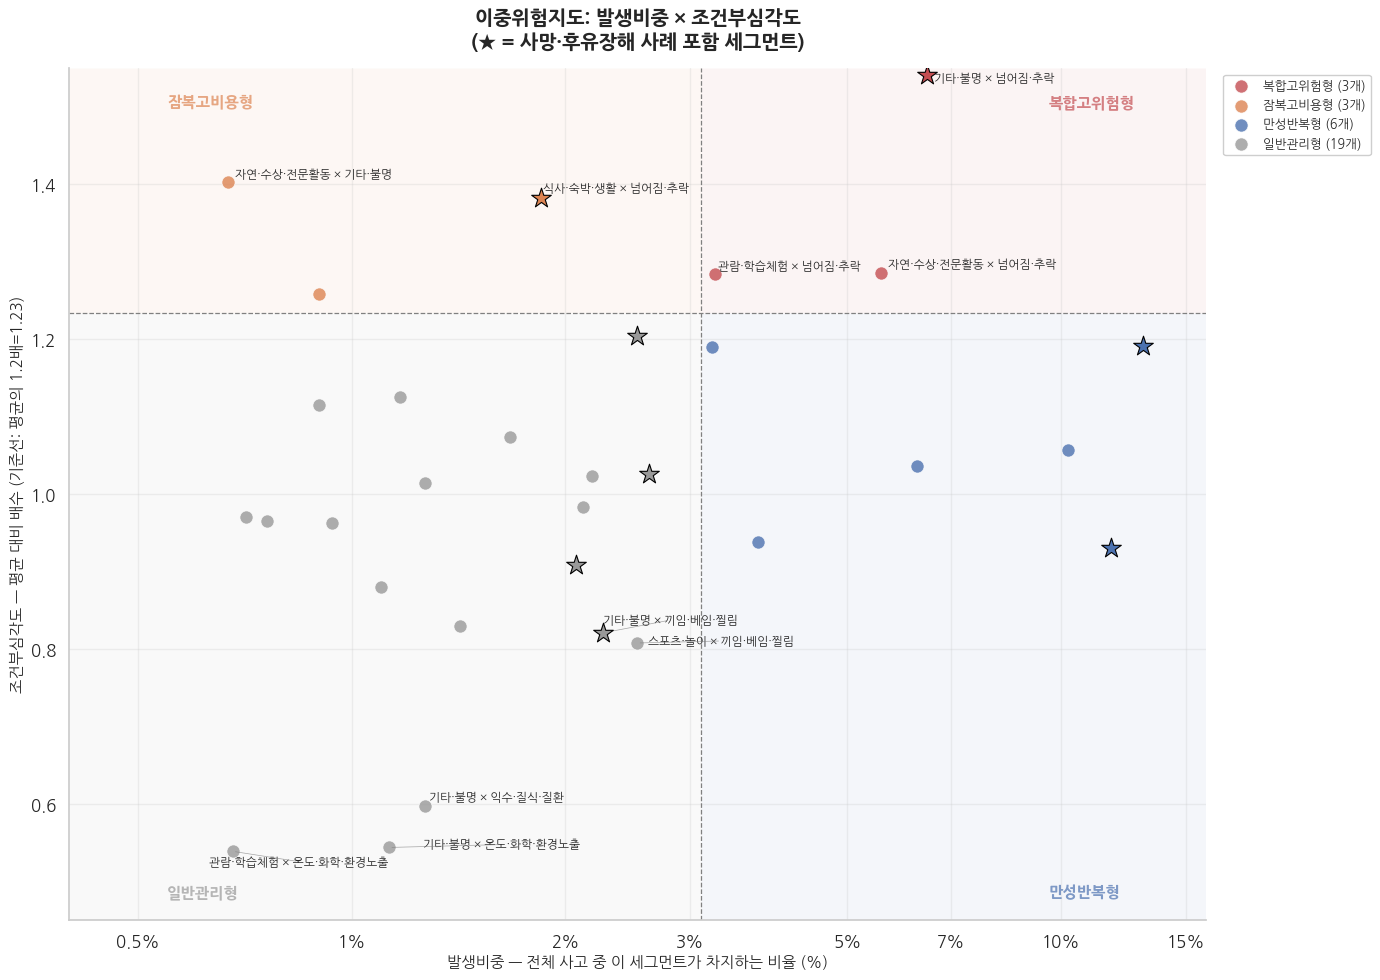


=== 잠복고비용형 (3개) ===


,세그먼트,발생비중,조건부심각도,극단결과_존재
26,자연·수상·전문활동 × 기타·불명,0.67,1.403,False
22,식사·숙박·생활 × 넘어짐·추락,1.85,1.383,True
25,식사·숙박·생활 × 온도·화학·환경노출,0.90,1.259,False



=== 복합고위험형 (3개) ===


,세그먼트,발생비중,조건부심각도,극단결과_존재
10,기타·불명 × 넘어짐·추락,6.48,1.542,True
28,자연·수상·전문활동 × 넘어짐·추락,5.58,1.286,False
1,관람·학습체험 × 넘어짐·추락,3.25,1.284,False



=== 만성반복형 (6개) ===


,세그먼트,발생비중,조건부심각도,극단결과_존재
17,스포츠·놀이 × 넘어짐·추락,13.06,1.191,True
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,3.22,1.190,False
19,스포츠·놀이 × 신체동작·염좌·과긴장,10.23,1.057,False
11,기타·불명 × 사람·물체와 충돌,6.26,1.036,False
12,기타·불명 × 신체동작·염좌·과긴장,3.74,0.939,False
18,스포츠·놀이 × 사람·물체와 충돌,11.78,0.931,True



=== 일반관리형 (19개) ===


,세그먼트,발생비중,조건부심각도,극단결과_존재
5,교통수단 이동·승하차 × 넘어짐·추락,2.53,1.205,True
7,교통수단 이동·승하차 × 신체동작·염좌·과긴장,1.17,1.125,False
24,식사·숙박·생활 × 신체동작·염좌·과긴장,0.90,1.115,False
3,관람·학습체험 × 신체동작·염좌·과긴장,1.67,1.074,False
8,기타·불명 × 기타·불명,2.63,1.026,True
29,자연·수상·전문활동 × 사람·물체와 충돌,2.18,1.024,False
6,교통수단 이동·승하차 × 사람·물체와 충돌,1.27,1.015,False
23,식사·숙박·생활 × 사람·물체와 충돌,2.12,0.983,False
27,자연·수상·전문활동 × 끼임·베임·찔림,0.71,0.971,False
20,식사·숙박·생활 × 기타·불명,0.76,0.966,False


In [47]:
# [참고] 축 조정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from adjustText import adjust_text

korean_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name or 'Malgun' in f.name]
plt.rcParams['font.family'] = korean_fonts[0] if korean_fonts else 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 사분면 기준 설정: F는 평균, S는 평균의 1.2배 (근거는 앞선 검증 결과 참고)
f_ref = segment_main['발생비중'].mean()
s_ref = segment_main['조건부심각도'].mean() * 1.2

def classify_quadrant_v2(row):
    high_freq = row['발생비중'] >= f_ref
    high_severity = row['조건부심각도'] >= s_ref
    if high_freq and high_severity:
        return '복합고위험형'
    elif not high_freq and high_severity:
        return '잠복고비용형'
    elif high_freq and not high_severity:
        return '만성반복형'
    else:
        return '일반관리형'

segment_main['사분면'] = segment_main.apply(classify_quadrant_v2, axis=1)
print(segment_main['사분면'].value_counts())

# 극단결과(사망·후유장해) 플래그 (이미 있다면 이 셀은 건너뛰어도 됨)
comp_main['극단결과'] = (comp_main['유족급여'] > 0) | (comp_main['장례비'] > 0) | (comp_main['장해급여'] > 0)

extreme_by_segment = (
    comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])]
    .groupby('세그먼트')['극단결과']
    .sum()
    .reset_index(name='극단결과_건수')
)
segment_main = segment_main.drop(columns=['극단결과_건수', '극단결과_존재'], errors='ignore')
segment_main = segment_main.merge(extreme_by_segment, on='세그먼트', how='left')
segment_main['극단결과_존재'] = segment_main['극단결과_건수'] > 0

colors_map = {'복합고위험형': '#C44E52', '잠복고비용형': '#DD8452', '만성반복형': '#4C72B0', '일반관리형': '#999999'}

fig, ax = plt.subplots(figsize=(14, 10))

x_min, x_max = 0.4, 16
y_min, y_max = 0.45, 1.55
y_frac = (s_ref - y_min) / (y_max - y_min)  # S 기준선(1.2배)의 y축 내 상대 위치

# 사분면 배경색
ax.axvspan(x_min, f_ref, ymin=y_frac, ymax=1, facecolor='#DD8452', alpha=0.06, zorder=0)
ax.axvspan(f_ref, x_max, ymin=y_frac, ymax=1, facecolor='#C44E52', alpha=0.06, zorder=0)
ax.axvspan(f_ref, x_max, ymin=0, ymax=y_frac, facecolor='#4C72B0', alpha=0.06, zorder=0)
ax.axvspan(x_min, f_ref, ymin=0, ymax=y_frac, facecolor='#999999', alpha=0.06, zorder=0)

# 점 (극단결과 없음: 원, 있음: 별)
for quadrant, color in colors_map.items():
    subset = segment_main[(segment_main['사분면'] == quadrant) & (~segment_main['극단결과_존재'])]
    ax.scatter(subset['발생비중'], subset['조건부심각도'], s=90, alpha=0.8, color=color,
               edgecolor='white', linewidth=0.6,
               label=f'{quadrant} ({(segment_main["사분면"]==quadrant).sum()}개)', zorder=3)

for quadrant, color in colors_map.items():
    subset = segment_main[(segment_main['사분면'] == quadrant) & (segment_main['극단결과_존재'])]
    ax.scatter(subset['발생비중'], subset['조건부심각도'], s=220, marker='*',
               color=color, edgecolor='black', linewidth=0.8, zorder=5)

ax.set_xscale('log')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
tick_values = [0.5, 1, 2, 3, 5, 7, 10, 15]
ax.set_xticks(tick_values)
ax.set_xticklabels([f'{v}%' for v in tick_values])

ax.axvline(f_ref, color='gray', linestyle='--', linewidth=0.9, zorder=1)
ax.axhline(s_ref, color='gray', linestyle='--', linewidth=0.9, zorder=1)

# 사분면 이름표
ax.text(0.55, 1.5, '잠복고비용형', fontsize=11, color='#DD8452', fontweight='bold', alpha=0.7)
ax.text(x_max*0.6, 1.5, '복합고위험형', fontsize=11, color='#C44E52', fontweight='bold', alpha=0.7)
ax.text(x_max*0.6, 0.48, '만성반복형', fontsize=11, color='#4C72B0', fontweight='bold', alpha=0.7)
ax.text(0.55, 0.48, '일반관리형', fontsize=11, color='#999999', fontweight='bold', alpha=0.7)

# 라벨: 상하위 15%만, 자동 겹침 방지
label_targets = segment_main[
    (segment_main['조건부심각도'] >= segment_main['조건부심각도'].quantile(0.85)) |
    (segment_main['조건부심각도'] <= segment_main['조건부심각도'].quantile(0.15))
]
texts = []
for _, row in label_targets.iterrows():
    texts.append(ax.text(row['발생비중'], row['조건부심각도'], row['세그먼트'], fontsize=8.5))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.7), expand_points=(1.5, 1.5))

ax.set_xlabel('발생비중 — 전체 사고 중 이 세그먼트가 차지하는 비율 (%)', fontsize=11)
ax.set_ylabel(f'조건부심각도 — 평균 대비 배수 (기준선: 평균의 1.2배={s_ref:.2f})', fontsize=11)
ax.set_title('이중위험지도: 발생비중 × 조건부심각도\n(★ = 사망·후유장해 사례 포함 세그먼트)', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, framealpha=0.95)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

# 사분면별 세그먼트 목록
for quadrant in ['잠복고비용형', '복합고위험형', '만성반복형', '일반관리형']:
    subset = segment_main[segment_main['사분면'] == quadrant].sort_values('조건부심각도', ascending=False)
    print(f"\n=== {quadrant} ({len(subset)}개) ===")
    display(subset[['세그먼트', '발생비중', '조건부심각도', '극단결과_존재']])

## 순위역전지수 계산

- 세그먼트 간 F, S 백분위 차이

In [48]:
# 순위역전지수 계산
segment_main['발생비중_백분위'] = segment_main['발생비중'].rank(pct=True) * 100
segment_main['조건부심각도_백분위'] = segment_main['조건부심각도'].rank(pct=True) * 100

segment_main['순위역전지수'] = (
    segment_main['조건부심각도_백분위'] - segment_main['발생비중_백분위']
).round(1)

display(
    segment_main[['세그먼트', '발생비중', '발생비중_백분위', '조건부심각도', '조건부심각도_백분위', '순위역전지수']]
    .sort_values('순위역전지수', ascending=False)
)

,세그먼트,발생비중,발생비중_백분위,조건부심각도,조건부심각도_백분위,순위역전지수
26,자연·수상·전문활동 × 기타·불명,0.67,3.225806,1.403,96.774194,93.5
25,식사·숙박·생활 × 온도·화학·환경노출,0.90,17.741935,1.259,83.870968,66.1
24,식사·숙박·생활 × 신체동작·염좌·과긴장,0.90,17.741935,1.115,67.741935,50.0
22,식사·숙박·생활 × 넘어짐·추락,1.85,48.387097,1.383,93.548387,45.2
7,교통수단 이동·승하차 × 신체동작·염좌·과긴장,1.17,32.258065,1.125,70.967742,38.7
27,자연·수상·전문활동 × 끼임·베임·찔림,0.71,9.677419,0.971,41.935484,32.3
20,식사·숙박·생활 × 기타·불명,0.76,12.903226,0.966,38.709677,25.8
3,관람·학습체험 × 신체동작·염좌·과긴장,1.67,45.161290,1.074,64.516129,19.4
5,교통수단 이동·승하차 × 넘어짐·추락,2.53,66.129032,1.205,80.645161,14.5
0,관람·학습체험 × 끼임·베임·찔림,0.94,22.580645,0.963,35.483871,12.9


In [49]:
top_underrated = segment_main.sort_values('순위역전지수', ascending=False).head(5)
top_overrated = segment_main.sort_values('순위역전지수').head(5)

print("[저평가된 위험] 빈도는 낮지만 심각도가 높은 세그먼트")
display(top_underrated[['세그먼트', '발생비중', '조건부심각도', '순위역전지수']])

print()
print("[과대평가된 위험] 빈도는 높지만 심각도가 낮은 세그먼트")
display(top_overrated[['세그먼트', '발생비중', '조건부심각도', '순위역전지수']])

[저평가된 위험] 빈도는 낮지만 심각도가 높은 세그먼트


,세그먼트,발생비중,조건부심각도,순위역전지수
26,자연·수상·전문활동 × 기타·불명,0.67,1.403,93.5
25,식사·숙박·생활 × 온도·화학·환경노출,0.90,1.259,66.1
24,식사·숙박·생활 × 신체동작·염좌·과긴장,0.90,1.115,50.0
22,식사·숙박·생활 × 넘어짐·추락,1.85,1.383,45.2
7,교통수단 이동·승하차 × 신체동작·염좌·과긴장,1.17,1.125,38.7



[과대평가된 위험] 빈도는 높지만 심각도가 낮은 세그먼트


,세그먼트,발생비중,조건부심각도,순위역전지수
18,스포츠·놀이 × 사람·물체와 충돌,11.78,0.931,-67.7
16,스포츠·놀이 × 끼임·베임·찔림,2.53,0.808,-53.2
12,기타·불명 × 신체동작·염좌·과긴장,3.74,0.939,-48.4
9,기타·불명 × 끼임·베임·찔림,2.26,0.821,-45.2
19,스포츠·놀이 × 신체동작·염좌·과긴장,10.23,1.057,-32.3


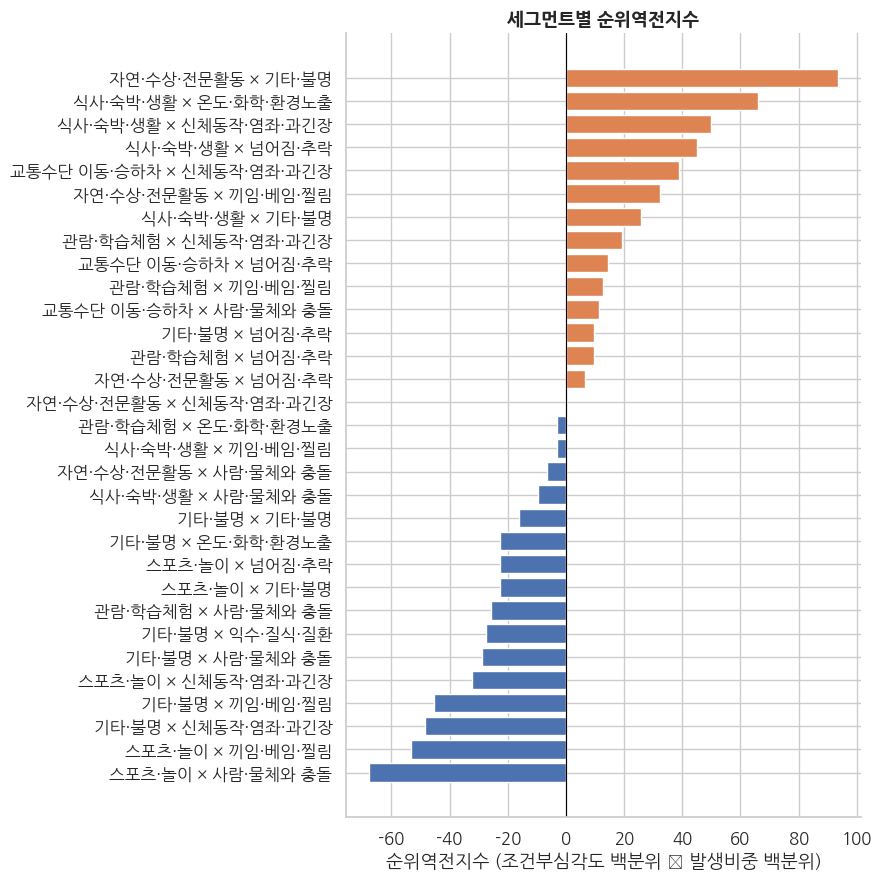

In [50]:
fig, ax = plt.subplots(figsize=(9, 9))

plot_data = segment_main.sort_values('순위역전지수')
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in plot_data['순위역전지수']]

ax.barh(plot_data['세그먼트'], plot_data['순위역전지수'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('순위역전지수 (조건부심각도 백분위 − 발생비중 백분위)')
ax.set_title('세그먼트별 순위역전지수', fontsize=13, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 통제가능성

- 세그먼트별 예방조치 서술
- 3~4개 범주로 분류하는 방식은 근거가 약함 (경계 기준 불명확)

In [51]:
mechanism_prevention = {
    '넘어짐·추락': {
        '예방조치': '바닥 정비, 조도 확보(75lux 이상), 이동통로 확보',
        '근거강도': '확인됨(안전보건공단 지침)'
    },
    '끼임·베임·찔림': {
        '예방조치': '위험 지점 사전 점검, 도구 사용법 지도',
        '근거강도': '일반 원칙(산업용 지침은 학교 맥락과 상이, 직접 인용 부적절)'
    },
    '사람·물체와 충돌': {
        '예방조치': '동선 분리, 인원 배치, 활동 전 질서지도',
        '근거강도': '일반 원칙'
    },
    '신체동작·염좌·과긴장': {
        '예방조치': '준비운동, 활동강도 사전조절',
        '근거강도': '일반 원칙'
    },
    '온도·화학·환경노출': {
        '예방조치': '환경조건 사전점검, 보호장비 지급',
        '근거강도': '일반 원칙'
    },
    '차량·교통수단 충격': {
        '예방조치': '승하차 구역 분리, 운전자격 확인',
        '근거강도': '일반 원칙'
    },
    '익수·질식·질환': {
        '예방조치': '전문 안전요원 배치, 응급구조체계 확인',
        '근거강도': '간접 근거(교육청 고위험활동 매뉴얼 - 수상활동 안전요원 의무배치)'
    },
    '기타·불명': {
        '예방조치': '원자료상 특정 불가',
        '근거강도': '해당 없음'
    }
}

segment_main['사고기전_split'] = segment_main['세그먼트'].str.split(' × ').str[1]
segment_main['예방조치'] = segment_main['사고기전_split'].map(lambda m: mechanism_prevention.get(m, {}).get('예방조치'))
segment_main['근거강도'] = segment_main['사고기전_split'].map(lambda m: mechanism_prevention.get(m, {}).get('근거강도'))

In [52]:
priority_segments = segment_main[segment_main['사분면'].isin(['잠복고비용형', '복합고위험형'])].copy()

display(
    priority_segments[['세그먼트', '사분면', '발생비중', '조건부심각도', '예방조치', '근거강도']]
    .sort_values('조건부심각도', ascending=False)
)

,세그먼트,사분면,발생비중,조건부심각도,예방조치,근거강도
10,기타·불명 × 넘어짐·추락,복합고위험형,6.48,1.542,"바닥 정비, 조도 확보(75lux 이상), 이동통로 확보",확인됨(안전보건공단 지침)
26,자연·수상·전문활동 × 기타·불명,잠복고비용형,0.67,1.403,원자료상 특정 불가,해당 없음
22,식사·숙박·생활 × 넘어짐·추락,잠복고비용형,1.85,1.383,"바닥 정비, 조도 확보(75lux 이상), 이동통로 확보",확인됨(안전보건공단 지침)
28,자연·수상·전문활동 × 넘어짐·추락,복합고위험형,5.58,1.286,"바닥 정비, 조도 확보(75lux 이상), 이동통로 확보",확인됨(안전보건공단 지침)
1,관람·학습체험 × 넘어짐·추락,복합고위험형,3.25,1.284,"바닥 정비, 조도 확보(75lux 이상), 이동통로 확보",확인됨(안전보건공단 지침)
25,식사·숙박·생활 × 온도·화학·환경노출,잠복고비용형,0.90,1.259,"환경조건 사전점검, 보호장비 지급",일반 원칙


## 통계적 검증

> 이중위험지도에서 확인된 "넘어짐·추락이 다른 사고기전보다 심각도가 높다"는 패턴이 우연이 아닌가 ?

In [53]:
import statsmodels.formula.api as smf
from scipy.stats import f_oneway

### ANOVA - 세그먼트 단위

In [54]:
segment_main['사고기전_split'] = segment_main['세그먼트'].str.split(' × ').str[1]
segment_main['사고상황_split'] = segment_main['세그먼트'].str.split(' × ').str[0]

# 사고기전 간 조건부심각도 차이
valid_mechanisms = segment_main['사고기전_split'].value_counts()
valid_mechanisms = valid_mechanisms[valid_mechanisms >= 3].index
groups_mech = [segment_main[segment_main['사고기전_split'] == m]['조건부심각도'].values for m in valid_mechanisms]
f_mech, p_mech = f_oneway(*groups_mech)
print(f"사고기전 간 조건부심각도 차이 - ANOVA: F={f_mech:.2f}, p={p_mech:.4f}")

# 사고상황 간 조건부심각도 차이
valid_situations = segment_main['사고상황_split'].value_counts()
valid_situations = valid_situations[valid_situations >= 3].index
groups_sit = [segment_main[segment_main['사고상황_split'] == s]['조건부심각도'].values for s in valid_situations]
f_sit, p_sit = f_oneway(*groups_sit)
print(f"사고상황 간 조건부심각도 차이 - ANOVA: F={f_sit:.2f}, p={p_sit:.4f}")

사고기전 간 조건부심각도 차이 - ANOVA: F=5.65, p=0.0014
사고상황 간 조건부심각도 차이 - ANOVA: F=0.99, p=0.4461


### 로지스틱 회귀 - 개별사고 단위

In [55]:
reg_data = comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])].copy()
reg_data['고비용'] = (reg_data['총보상금'] >= 5_000_000).astype(int)
reg_data['넘어짐추락여부'] = (reg_data['사고기전'] == '넘어짐·추락').astype(int)

print(f"분석 대상: {len(reg_data)}건, 고비용 {reg_data['고비용'].sum()}건({reg_data['고비용'].mean()*100:.2f}%)")

분석 대상: 5004건, 고비용 32건(0.64%)


In [56]:
# 모델 1: 통제변수 없음 (가장 단순, 순수 효과)
model_simple = smf.logit("고비용 ~ 넘어짐추락여부", data=reg_data)
result_simple = model_simple.fit(disp=0)
print(f"[모델1: 통제변수 없음] 오즈비={np.exp(result_simple.params['넘어짐추락여부']):.2f}, "
      f"p={result_simple.pvalues['넘어짐추락여부']:.4f}")

[모델1: 통제변수 없음] 오즈비=2.08, p=0.0409


In [57]:
# 모델 2: 사고상황 + 발생연도 통제
model_controlled = smf.logit("고비용 ~ 넘어짐추락여부 + C(사고상황) + C(지급연도)", data=reg_data)
result_controlled = model_controlled.fit(disp=0)
print(f"[모델2: 사고상황+연도 통제] 오즈비={np.exp(result_controlled.params['넘어짐추락여부']):.2f}, "
      f"p={result_controlled.pvalues['넘어짐추락여부']:.4f}")

[모델2: 사고상황+연도 통제] 오즈비=1.95, p=0.0688


In [58]:
# 참고: 학교급 확인 (완전분리 문제 사전 점검)
print(pd.crosstab(reg_data['학교급'], reg_data['고비용']))
# 유치원·기타학교는 고비용 0건 -> 학교급 포함 시 완전(준)분리 발생, 모델 불안정
# 이에 학교급은 통제변수에서 제외하고 모델1, 2만 최종 채택

고비용      0   1
학교급           
고등학교  1263  18
기타학교    40   0
유치원    523   0
중학교   1443   8
초등학교  1664   5
특수학교    39   1


## 관리포착률 비교

In [59]:
import matplotlib.pyplot as plt

# 세그먼트별 500만원 이상 고비용건수 확인 (없다면 재계산)
if '고비용건수_500만' not in segment_main.columns:
    comp_main['고비용여부_500만'] = comp_main['총보상금'] >= 5_000_000
    high_cost_by_segment = (
        comp_main[comp_main['세그먼트'].isin(segment_main['세그먼트'])]
        .groupby('세그먼트')['고비용여부_500만']
        .sum()
        .reset_index(name='고비용건수_500만')
    )
    segment_main = segment_main.merge(high_cost_by_segment, on='세그먼트', how='left')

total_high_cost = segment_main['고비용건수_500만'].sum()
total_accidents = segment_main['사고건수'].sum()
print(f"전체 고비용 사고: {total_high_cost}건 / 전체 사고: {total_accidents}건")

전체 고비용 사고: 32건 / 전체 사고: 7081건


In [60]:
# 방식 1: 사고건수(발생비중) 중심 순위
ranking_freq = segment_main.sort_values('발생비중', ascending=False).reset_index(drop=True)

# 방식 2: 이중위험지도 우선순위 (사분면 우선 + 사분면 내 조건부심각도 순)
quadrant_priority = {'복합고위험형': 0, '잠복고비용형': 1, '만성반복형': 2, '일반관리형': 3}
segment_main['사분면_우선순위'] = segment_main['사분면'].map(quadrant_priority)
ranking_dual = segment_main.sort_values(
    ['사분면_우선순위', '조건부심각도'], ascending=[True, False]
).reset_index(drop=True)

In [61]:
# N(관리 세그먼트 수)을 1~31까지 늘려가며, 두 방식의 누적 고비용 포착률 계산
n_range = range(1, len(segment_main) + 1)

capture_freq = [ranking_freq.head(n)['고비용건수_500만'].sum() / total_high_cost * 100 for n in n_range]
capture_dual = [ranking_dual.head(n)['고비용건수_500만'].sum() / total_high_cost * 100 for n in n_range]

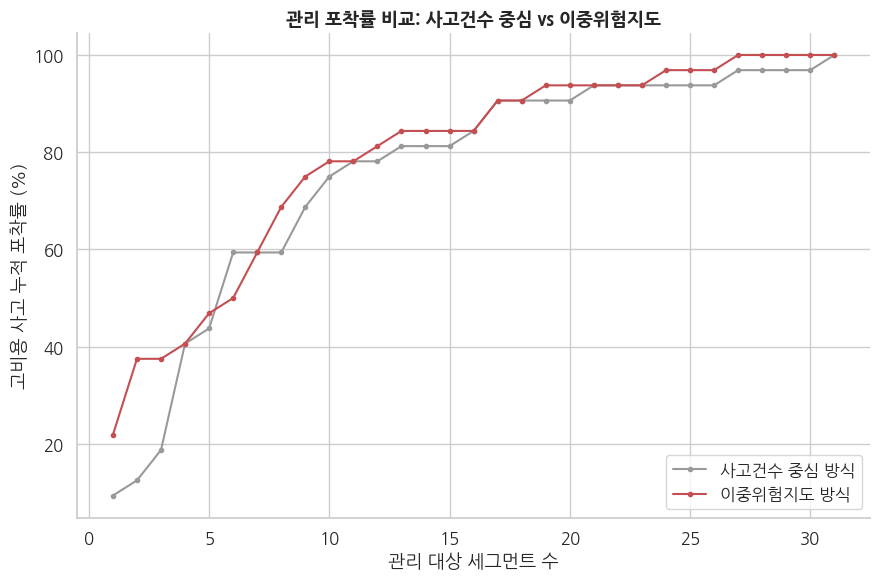

In [62]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(list(n_range), capture_freq, marker='o', markersize=3, color='#999999', label='사고건수 중심 방식')
ax.plot(list(n_range), capture_dual, marker='o', markersize=3, color='#C44E52', label='이중위험지도 방식')

ax.set_xlabel('관리 대상 세그먼트 수')
ax.set_ylabel('고비용 사고 누적 포착률 (%)')
ax.set_title('관리 포착률 비교: 사고건수 중심 vs 이중위험지도', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [63]:
# 주요 지점(상위 10%, 20%, 30% 관리)에서 두 방식의 포착률 차이 표로 정리
check_points = [3, 6, 9, 12, 15]  # 31개 중 약 10%~50%
comparison_table = pd.DataFrame({
    '관리세그먼트수': check_points,
    '관리비율(%)': [round(n/len(segment_main)*100, 1) for n in check_points],
    '사고건수방식_포착률': [capture_freq[n-1] for n in check_points],
    '이중위험지도_포착률': [capture_dual[n-1] for n in check_points],
})
comparison_table['포착률차이(%p)'] = (
    comparison_table['이중위험지도_포착률'] - comparison_table['사고건수방식_포착률']
).round(1)

display(comparison_table)

,관리세그먼트수,관리비율(%),사고건수방식_포착률,이중위험지도_포착률,포착률차이(%p)
0,3,9.7,18.750,37.500,18.8
1,6,19.4,59.375,50.000,-9.4
2,9,29.0,68.750,75.000,6.2
3,12,38.7,78.125,81.250,3.1
4,15,48.4,81.250,84.375,3.1


## 기타

### 민감도 분석

In [64]:
# 500만원 대신 300만원, 700만원으로 바꿔도 넘어짐·추락 오즈비가 비슷하게 유지되는지 확인
for threshold in [3_000_000, 5_000_000, 7_000_000]:
    reg_data['고비용_임계값테스트'] = (reg_data['총보상금'] >= threshold).astype(int)
    model_test = smf.logit("고비용_임계값테스트 ~ 넘어짐추락여부", data=reg_data)
    result_test = model_test.fit(disp=0)
    odds = np.exp(result_test.params['넘어짐추락여부'])
    p = result_test.pvalues['넘어짐추락여부']
    print(f"임계값 {threshold:,}원: 오즈비={odds:.2f}, p={p:.4f}")

임계값 3,000,000원: 오즈비=1.77, p=0.0062
임계값 5,000,000원: 오즈비=2.08, p=0.0409
임계값 7,000,000원: 오즈비=1.61, p=0.2874


### 시간적 재현성 검증

In [65]:
# 2023-2024로 사고기전별 조건부심각도 계산, 2025와 비교
early_data = comp_main[comp_main['지급연도'].isin([2023, 2024])]
late_data = comp_main[comp_main['지급연도'] == 2025]

early_severity = early_data.groupby('사고기전')['총보상금'].apply(
    lambda x: (x >= 5_000_000).mean()
).sort_values(ascending=False)
late_severity = late_data.groupby('사고기전')['총보상금'].apply(
    lambda x: (x >= 5_000_000).mean()
).sort_values(ascending=False)

print("2023-2024 기준 사고기전별 고비용비율 순위")
print(early_severity)
print()
print("2025 기준 사고기전별 고비용비율 순위")
print(late_severity)

2023-2024 기준 사고기전별 고비용비율 순위
사고기전
차량·교통수단 충격     0.333333
기타·불명          0.017391
온도·화학·환경노출     0.009009
넘어짐·추락         0.007225
사람·물체와 충돌      0.004592
끼임·베임·찔림       0.003802
신체동작·염좌·과긴장    0.003110
익수·질식·질환       0.000000
Name: 총보상금, dtype: float64

2025 기준 사고기전별 고비용비율 순위
사고기전
익수·질식·질환       0.025641
넘어짐·추락         0.014493
기타·불명          0.010101
신체동작·염좌·과긴장    0.008380
끼임·베임·찔림       0.000000
사람·물체와 충돌      0.000000
온도·화학·환경노출     0.000000
Name: 총보상금, dtype: float64


### 사고기전 단독 예측 vs 사고상황×사고기전 결합 예측 비교

In [66]:
# 사고기전 평균으로 예측한 심각도 산출
segment_main['기전예측_심각도'] = segment_main.groupby('사고기전_split')['조건부심각도'].transform('mean')

# 실제값과 기전예측값의 차이(잔차) = 사고상황이 더해주는 효과
segment_main['상호작용잔차'] = segment_main['조건부심각도'] - segment_main['기전예측_심각도']

display(
    segment_main[['세그먼트', '사고기전_split', '조건부심각도', '기전예측_심각도', '상호작용잔차']]
    .sort_values('상호작용잔차', ascending=False)
)

,세그먼트,사고기전_split,조건부심각도,기전예측_심각도,상호작용잔차
25,식사·숙박·생활 × 온도·화학·환경노출,온도·화학·환경노출,1.259,0.780667,0.478333
26,자연·수상·전문활동 × 기타·불명,기타·불명,1.403,1.056250,0.346750
10,기타·불명 × 넘어짐·추락,넘어짐·추락,1.542,1.315167,0.226833
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,신체동작·염좌·과긴장,1.190,1.083333,0.106667
27,자연·수상·전문활동 × 끼임·베임·찔림,끼임·베임·찔림,0.971,0.888600,0.082400
0,관람·학습체험 × 끼임·베임·찔림,끼임·베임·찔림,0.963,0.888600,0.074400
22,식사·숙박·생활 × 넘어짐·추락,넘어짐·추락,1.383,1.315167,0.067833
11,기타·불명 × 사람·물체와 충돌,사람·물체와 충돌,1.036,0.983000,0.053000
7,교통수단 이동·승하차 × 신체동작·염좌·과긴장,신체동작·염좌·과긴장,1.125,1.083333,0.041667
29,자연·수상·전문활동 × 사람·물체와 충돌,사람·물체와 충돌,1.024,0.983000,0.041000


In [67]:
# 두 방식 각각의 고위험 판정
# 기전만 고려한 고위험 판정
mech_threshold = segment_main['기전예측_심각도'].mean() * 1.2
segment_main['기전기준_고위험'] = segment_main['기전예측_심각도'] >= mech_threshold

# 상황+기전(현재 방식)을 고려한 고위험 판정
current_threshold = segment_main['조건부심각도'].mean() * 1.2
segment_main['현재기준_고위험'] = segment_main['조건부심각도'] >= current_threshold

print(f"사고기전만 고려 시 고위험 세그먼트: {segment_main['기전기준_고위험'].sum()}개")
print(f"사고상황+사고기전 고려 시 고위험 세그먼트: {segment_main['현재기준_고위험'].sum()}개")

사고기전만 고려 시 고위험 세그먼트: 6개
사고상황+사고기전 고려 시 고위험 세그먼트: 6개


In [68]:
# 두 방식의 일치·불일치 확인
comparison_table = pd.crosstab(
    segment_main['기전기준_고위험'], segment_main['현재기준_고위험'],
    rownames=['기전만 고려'], colnames=['상황+기전 고려']
)
display(comparison_table)

# 판정이 달라진 세그먼트만 추출 (핵심 결과)
changed = segment_main[segment_main['기전기준_고위험'] != segment_main['현재기준_고위험']]

display(
    changed[['세그먼트', '사고기전_split', '조건부심각도', '기전예측_심각도', '상호작용잔차',
              '기전기준_고위험', '현재기준_고위험']]
    .sort_values('상호작용잔차', ascending=False)
)

상황+기전 고려,False,True
기전만 고려,,
False,23,2
True,2,4


,세그먼트,사고기전_split,조건부심각도,기전예측_심각도,상호작용잔차,기전기준_고위험,현재기준_고위험
25,식사·숙박·생활 × 온도·화학·환경노출,온도·화학·환경노출,1.259,0.780667,0.478333,False,True
26,자연·수상·전문활동 × 기타·불명,기타·불명,1.403,1.056250,0.346750,False,True
5,교통수단 이동·승하차 × 넘어짐·추락,넘어짐·추락,1.205,1.315167,-0.110167,True,False
17,스포츠·놀이 × 넘어짐·추락,넘어짐·추락,1.191,1.315167,-0.124167,True,False
